#483 Midterm Progress Report - Real or Fake? By The Review Inspectors



In this project, we focus specifically on detecting synthetic copy paste style spam bots in online reviews. These bots typically generate short, generic, highly positive or negative reviews that mimic real user language but lack meaningful variation.

To study this, we worked with a large dataset of over 600,000 real reviews. Due to the lack of labeled bot data, we generated synthetic fake reviews using AI that mimic common spam patterns (ex: repeated phrases, generic sentiment, and minimal detail).

We then combined the real and synthetic reviews into a single dataset and applied both classification models and unsupervised clustering techniques to analyze whether fake reviews could be detected based on text patterns alone.

This matters because many online platforms like yelp get flooded with fake reviews and these fake reviews destroy ratings and mislead customers and make it harder for sellers to keep a good reputation.
We want to make a system that predicts and tags reviews as either being fake or genuine and we want to group the reviews based on writing style to reveal some underlying patterns that may help our model decide more accurately whether a review is real or not.
This matters because it will help with trust wihtin the shopping communication potential buyers will trust ratings more, businesses and sellers get the reputation they deserve.

In [ ]:
#set up from the colabs
!pip -q install pyspark
!pip -q install -U PyDrive2
!apt-get -qq update
!apt-get -qq install -y openjdk-17-jdk-headless

import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [ ]:
BASE_PATH = "/content/drive/MyDrive/483_Project/Datasets"

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

# Auth user
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import pyspark
from pyspark.sql import *
from pyspark.sql.functions import *
from pyspark import SparkContext, SparkConf
from pyspark.sql import SparkSession

from pyspark.ml.feature import Tokenizer, StopWordsRemover, HashingTF, IDF, StringIndexer
from pyspark.ml.feature import VectorAssembler

In [ ]:
spark = SparkSession.builder \
    .config("spark.driver.memory", "5g") \
    .getOrCreate()
sc = spark.sparkContext

In [ ]:
from google.colab import drive
drive.flush_and_unmount()
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:

TRAIN_PATH = os.path.join(BASE_PATH, "yelp_train_exp.csv")
TEST_PATH = os.path.join(BASE_PATH, "yelp_test_exp.csv")


# print("TRAIN_PATH:", TRAIN_PATH)
# print("TEST_PATH:", TEST_PATH)
# pd.read_csv(TRAIN_PATH)["is_fake"].value_counts()


#NOTE: the data i put here is likely not gonna be used, loaded it on the drive just to test but this data is pretty old 2019-2021...we should probably find
#newer supplmental datasets to use with the yelp API

# TRAIN_PATH = os.path.join(BASE_PATH, "train.csv")
# TEST_PATH = os.path.join(BASE_PATH, "test.csv")
# YELP_PATH = os.path.join(BASE_PATH, "yelp.csv")


# print("Train exists?", os.path.exists(TRAIN_PATH))
# print("Test exists?", os.path.exists(TEST_PATH))
# print("Yelp exists?", os.path.exists(YELP_PATH))



TRAIN_PATH: /content/drive/MyDrive/483_Project/Datasets/yelp_train_exp.csv
TEST_PATH: /content/drive/MyDrive/483_Project/Datasets/yelp_test_exp.csv


,count
is_fake,
False,20000
True,4000


In [ ]:
import pandas as pd

#note:  smaller files can just be loaded normally
# test_df = pd.read_csv(TEST_PATH)
# yelp_df = pd.read_csv(YELP_PATH)

# #this is a huge file, so im only loading the first 100k rows
# train_df = pd.read_csv(TRAIN_PATH, nrows=100000)
# print(test_df.shape)
# print(yelp_df.shape)
# print(train_df.shape)


In [ ]:
import tarfile

#this particular dataset is in a diff format = diff loading mechanism
# TGZ_PATH = os.path.join(BASE_PATH, "amazon_review_polarity_csv.tgz")

# with tarfile.open(TGZ_PATH, "r:gz") as tar:
#     tar.extractall(BASE_PATH)

# print("Done extracting files")


##Step 1: Data Cleaning

By Coda




As mentioned, we began with a large dataset of real reviews and sampled a manageable subset for analysis. The text data was cleaned by removing punctuation, lowercasing, and filtering out unnecessary tokens. We also filtered by randomly sampling businesses the contain the word "restaurant" and randomly sampled 20k reviews. We did see that there was more real reviews than fake ones but that trend exists in the original dataset, so we believed it was not a concern for the specific type of bot we are focused on.

To simulate bot behavior, we generated synthetic fake reviews using AI based on known spam patterns such as repetitive phrasing, extreme sentiment, and low informational content.

The real and synthetic datasets were then merged and labeled using an is_fake column, allowing us to evaluate both supervised and unsupervised methods.

We also looked at articles about how fake bot reviews look like in order to make sure that AI was generating the right type of reviews for our labeling

Ex: https://thriveagency.com/news/how-to-spot-fake-yelp-reviews-and-what-to-do-next/


#### NOTE: we created new CSV's with out new and filtered dataset, hence why all the code is hidden but is still here for review.

###Loading the data

In [ ]:
# @title
import json
import os
import pandas as pd

REVIEW_PATH   = os.path.join(BASE_PATH, "yelp_academic_dataset_review.json")
USER_PATH     = os.path.join(BASE_PATH, "yelp_academic_dataset_user.json")
BUSINESS_PATH = os.path.join(BASE_PATH, "yelp_academic_dataset_business.json")

# yelp doesn't have a restaurant flag so we match on category string
RESTAURANT_CATEGORIES = {c.lower() for c in {"Restaurants"}}

# build restaurant ID set {business_id: state}
restaurant_businesses = {}
with open(BUSINESS_PATH, "r", encoding="utf-8") as f:
    for line in f:
        record = json.loads(line)
        categories = record.get("categories")
        if not categories:
            continue
        if isinstance(categories, str):
            categories = [c.strip() for c in categories.split(",")]
        if any(c.strip().lower() in RESTAURANT_CATEGORIES for c in categories):
            restaurant_businesses[record["business_id"]] = record.get("state")

restaurant_business_ids = set(restaurant_businesses.keys())
print(f"Restaurant businesses found: {len(restaurant_business_ids):,}")

# load 2018/9 restaurant reviews
chunk = []
reviews_chunks = []
needed_user_ids = set()

with open(REVIEW_PATH, "r", encoding="utf-8") as f:
    for line in f:
        record = json.loads(line)
        if record["business_id"] not in restaurant_business_ids:
            continue
        if record["date"][:4] not in ("2018", "2019"):
          continue
        needed_user_ids.add(record["user_id"])
        chunk.append({
            "review_id":   record["review_id"],
            "user_id":     record["user_id"],
            "business_id": record["business_id"],
            "stars":       record["stars"],
            "date":        record["date"],
            "text":        record["text"]
        })
        if len(chunk) == 1000000:
            reviews_chunks.append(pd.DataFrame(chunk))
            chunk = []
if chunk:
    reviews_chunks.append(pd.DataFrame(chunk))

reviews = pd.concat(reviews_chunks, ignore_index=True)
del reviews_chunks
print(f"Restaurant reviews loaded: {len(reviews):,}")

# load only users who appear in the reviews above
chunk = []
users_chunks = []

with open(USER_PATH, "r", encoding="utf-8") as f:
    for line in f:
        record = json.loads(line)
        if record["user_id"] not in needed_user_ids:
            continue
        friends = (record.get("friends") or "").strip()
        friend_count = 0 if friends in ("None", "") else len([x for x in friends.split(",") if x.strip()])
        chunk.append({
            "user_id":       record["user_id"],
            "name":          record["name"],
            "review_count":  record["review_count"],
            "yelping_since": record["yelping_since"],
            "friend_count":  friend_count,
            "useful":        record["useful"],
            "funny":         record["funny"],
            "cool":          record["cool"],
            "fans":          record["fans"]
        })
        if len(chunk) == 1000000:
            users_chunks.append(pd.DataFrame(chunk))
            chunk = []
if chunk:
    users_chunks.append(pd.DataFrame(chunk))

users = pd.concat(users_chunks, ignore_index=True)
del users_chunks
print(f"Users loaded: {len(users):,}")

# build business lookup table for state joining later
business_df = pd.DataFrame([
    {"business_id": bid, "state": state}
    for bid, state in restaurant_businesses.items()
])
del restaurant_businesses
print(f"Business lookup table: {len(business_df):,} rows")

Restaurant businesses found: 52,268
Restaurant reviews loaded: 1,218,962
Users loaded: 528,218
Business lookup table: 52,268 rows


###Clean Data


In [ ]:
# @title
# # @title
# #Based on this the data set is already cleaned
# print(reviews.isnull().sum())
# print(users.isnull().sum())


review_id      0
user_id        0
business_id    0
stars          0
date           0
text           0
dtype: int64
user_id          0
name             0
review_count     0
yelping_since    0
friend_count     0
useful           0
funny            0
cool             0
fans             0
dtype: int64


###Merge/Join Data

In [ ]:
# @title
# # @title
# #Join the two dataframes together
# df = reviews.merge(users, on="user_id", how="left")
# df = df.merge(business_df, on="business_id", how="left")

# df = df.dropna(subset=["name"]) #cleaning data post merge

# print(f"Joined dataframe rows: {len(df):,}")
# print(f"Joined dataframe cols: {df.columns.tolist()}")

Joined dataframe rows: 1,218,962
Joined dataframe cols: ['review_id', 'user_id', 'business_id', 'stars', 'date', 'text', 'name', 'review_count', 'yelping_since', 'friend_count', 'useful', 'funny', 'cool', 'fans', 'state']


In [ ]:
# @title
# # @title
# import builtins
# import random
# import string
# import builtins
# import numpy as np
# import pandas as pd
# from datetime import datetime, timedelta

# random.seed(42)
# np.random.seed(42)
# # from text column
# df["review_length"] = df["text"].str.len()
# df["word_count"]    = df["text"].str.split().str.len()

# # from yelping_since column
# df["yelping_since"]    = pd.to_datetime(df["yelping_since"])
# df["account_age_days"] = (pd.Timestamp.today() - df["yelping_since"]).dt.days

# # rate of reviewing --> if it's high then data could be fake
# df["reviews_per_day"] = df["review_count"] / df["account_age_days"].replace(0, 1)

# # from date column
# df["date"] = pd.to_datetime(df["date"])

# # number of states a user has reviewed in --> many states could mean fake
# df["states_reviewed_in"] = df.groupby("user_id")["state"].transform("nunique")

# # number of reviews a user left on the same day --> bursts could mean fake
# df["reviews_same_day"] = df.groupby(["user_id", "date"])["review_id"].transform("count")

# df["is_fake"] = False #true for all coming from yelp academic dataset

# # tunable thresholds
# MIN_WORD_COUNT     = 3
# BURST_THRESHOLD    = 2
# VELOCITY_THRESHOLD = 1.0
# FAKE_THRESHOLD     = 3

# # spam signal flags
# df["is_short_review"] = (
#     df["word_count"] < np.random.randint(30, 61, size=len(df))
# ).astype(int)

# df["is_extreme_rating"] = (
#     (df["stars"].isin([1, 5])) & (np.random.random(len(df)) < 0.7)
# ).astype(int)

# df["is_low_social"] = (
#     (df["friend_count"] <= 2) & (df["fans"] == 0) & (df["useful"] <= 1)
# ).astype(int)

# df["is_single_review_account"] = (
#     df["review_count"] <= np.random.randint(2, 6, size=len(df))
# ).astype(int)

# df["is_high_velocity"] = (
#     df["reviews_per_day"] >= np.random.uniform(0.8, 1.5, size=len(df))
# ).astype(int)

# spam_flag_cols = [
#     "is_short_review",
#     "is_extreme_rating",
#     "is_low_social",
#     "is_single_review_account",
#     "is_high_velocity"
# ]

# df["spam_score"] = df[spam_flag_cols].sum(axis=1)

# print(f"Spam score distribution:\n{df['spam_score'].value_counts().sort_index().to_string()}")
# print(f"\nExtreme rating breakdown:\n{df['is_extreme_rating'].value_counts().to_string()}")
# print("\nSpot-check high spam_score reviews:")
# print(df[df["spam_score"] >= FAKE_THRESHOLD][["text", "stars", "is_extreme_rating", "spam_score"]].head(10))

Spam score distribution:
spam_score
0    425541
1    451451
2    236538
3     82760
4     22672

Extreme rating breakdown:
is_extreme_rating
0    686278
1    532684

Spot-check high spam_score reviews:
                                                 text  stars  \
14  Cindy is the best! Great food and service. Foo...    5.0   
24  Exactly as bougie and casual at the same time ...    5.0   
29  OMG the Mediterranean chicken quesadillas what...    5.0   
31  I love this restaurant. The owners are the nic...    5.0   
41  First time I went to Earl's new American kitch...    1.0   
73  Best chicken you could ever hope for in bourbo...    5.0   
78  Consistent quality and service.  Love the #1 D...    5.0   
79  Creative food and good. We get coffee or tea w...    5.0   
89  The bayou burger is literally the best burger ...    5.0   
98  the foods great, but no buflight on tap.i love...    1.0   

    is_extreme_rating  spam_score  
14                  1           4  
24                  1

In [ ]:
# @title
# # @title
# df = df.sample(n=25000, random_state=42).reset_index(drop=True)

# print(f"Total reviews after sample: {len(df):,}")
# print(f"Unique businesses: {df['business_id'].nunique():,}")

Total reviews after sample: 25,000
Unique businesses: 12,561


In [ ]:
# @title
# real_only_df = df.copy()
# real_only_df["is_fake"] = False

# real_only_df.to_csv(
#     os.path.join(BASE_PATH, "yelp_real_only.csv"),
#     index=False,
#     encoding="utf-8"
# )

# print("saved yelp_real_only.csv")
# print(real_only_df["is_fake"].value_counts().to_string())
# print(f"rows saved: {len(real_only_df):,}")
# print(f"avg word count: {real_only_df['word_count'].mean():.1f}")

saved yelp_real_only.csv
is_fake
False    25000
rows saved: 25,000
avg word count: 92.9


# Generating fake reviews via ai

In [ ]:
# @title
# import random
# import builtins

# OPENERS = [
#     "Food took forever but ended up being better than I expected",
#     "Not sure why this place has such split reviews, but my experience was mostly fine",
#     "Ordered takeout because I didn't feel like cooking and it held up okay",
#     "The fries were probably the best part of the meal, honestly",
#     "Service was nice, kitchen was just moving kind of slow",
#     "This place was louder than I expected and that sort of shaped the whole meal",
#     "The photos made it look a little better than it actually was",
#     "My friend liked it more than I did",
#     "I wanted to like this more than I actually did",
#     "Nothing was terrible, it just never really came together for me",
#     "The first few bites were promising and then it kind of leveled out",
#     "Portion size looked small at first but it was actually enough",
#     "Parking was annoying and I was already in a bad mood by the time I got inside",
#     "The wait was longer than it should've been for a pretty normal dinner service",
#     "The sauce carried most of the meal",
#     "Dessert saved this a little",
#     "The soup was better than the sandwich, which I wasn't expecting",
#     "Honestly I think I ordered the wrong thing",
#     "This is one of those places where I can see other people loving it more than I did",
#     "It tasted fresh, just not especially memorable",
#     "I get the appeal, I just don't totally share it",
#     "For the price I expected a little more care",
#     "The food came out fast, which was good because we were starving",
#     "One of those meals where nothing is exactly wrong but you're not excited either",
# ]

# VISIT_OPENERS = [
#     "Stopped by after work because I was nearby and hungry",
#     "First time ordering from here and I honestly wasn't sure what to expect",
#     "Got takeout from here twice now so I feel like I can say a little more",
#     "Had brunch here over the weekend and it was kind of a mixed bag",
#     "Ended up here pretty late, maybe around 9:30, because everything else nearby had a wait",
#     "Tried this spot for lunch during a work break",
#     "This was a delivery order on a night when I really did not want to cook",
#     "Went with family on a Sunday and it was louder than I expected",
# ]

# FOOD_DETAILS = [
#     "The fries were hot and crisp but the burger itself was a little messy and kept sliding apart",
#     "I got the chicken bowl and it was filling, though the rice could have used a bit more seasoning",
#     "The ramen broth had good flavor, maybe a little salty, but I still finished most of it",
#     "We shared dumplings first and those were probably the best thing on the table",
#     "The tacos tasted fresh enough, just smaller than I pictured from the photos",
#     "My pasta was decent and not overcooked, which I appreciated because that happens a lot",
#     "The sandwich was fine, not bad, just not something I'm still thinking about two days later",
#     "The wings had a good kick to them but the texture was inconsistent",
#     "I liked the soup more than the entree honestly",
#     "The portion size looked small at first but ended up being enough",
#     "Dessert was weirdly the highlight, which I wasn't expecting at all",
#     "The food came out looking really good, tasted solid, then kind of leveled off after a few bites",
# ]

# SERVICE_DETAILS = [
#     "Service was friendly, just kind of slow once the room filled up",
#     "Our server was nice and checked in enough without hovering",
#     "The staff seemed tired but still polite",
#     "Nobody was rude or anything, it just took a while to get water refilled",
#     "They mixed up one side dish and fixed it pretty fast",
#     "Ordering was easy but pickup took about ten extra minutes past the quoted time",
#     "The host got us seated quickly, which I appreciated because we didn't have a reservation",
#     "It felt a little understaffed, especially near the end of the meal",
#     "Delivery showed up warm, so no complaints there",
#     "For a busy night they handled it okay",
# ]

# ATMOSPHERE_DETAILS = [
#     "Inside is casual and a little cramped, but not in a terrible way",
#     "The music was louder than it needed to be",
#     "Parking was annoying, although that's probably more about the area than the restaurant",
#     "It was clean enough and the tables were being turned over pretty fast",
#     "The place has that neighborhood spot feel, not fancy at all",
#     "Outdoor seating looked nicer than the inside honestly",
#     "Nothing about the space really stood out, which is maybe why the food had to do more",
#     "It was crowded but still moved along",
# ]

# PRICE_DETAILS = [
#     "Price felt a touch high for what it was",
#     "For the amount of food, I thought the cost was fair",
#     "I've paid more for worse meals, so I'm not mad about it",
#     "It landed in that middle zone where you expect a little more but not a lot more",
#     "Not cheap exactly, but not ridiculous either",
# ]

# CLOSERS = [
#     "I'd maybe go back, but I'd order differently next time.",
#     "Not a bad stop, just not one I'm rushing to repeat.",
#     "I can see why people like it, even if I wasn't fully sold.",
#     "There were a couple things I liked and a couple things I probably wouldn't get again.",
#     "Kind of landed in the middle for me.",
#     "I left full, which at least counts for something.",
#     "It was decent, just a little uneven.",
#     "I wouldn't write it off, but I also wouldn't hype it up.",
#     "Maybe better dine-in than delivery, hard to tell.",
#     "This feels like a place where your order choice matters a lot.",
# ]

# EXTRA_DETAILS = [
#     "The menu wasn't huge, which I usually prefer.",
#     "They were out of one thing I originally wanted.",
#     "The wait wasn't awful, just longer than I expected for the time of day.",
#     "My friend liked their dish more than I liked mine.",
#     "The leftovers held up okay the next day.",
#     "The sauces helped more than I thought they would.",
#     "Nothing tasted old or stale, so that's always a plus.",
#     "I kept going back and forth while eating it, which probably says everything.",
#     "It looked better in person than in the online photos, weirdly enough.",
#     "I've definitely had more memorable meals for the same price.",
# ]

# GENERIC_POSITIVE = [
#     "Everything came out hot and the staff was friendly",
#     "Food was fresh and service was quick",
#     "Really liked the atmosphere and the portions were decent",
#     "Solid food, nice staff, and not much of a wait",
#     "Everything was tasty and the place felt clean",
#     "The food was good and the service was easygoing",
#     "Pretty smooth experience from start to finish",
#     "No big complaints, just a nice meal",
# ]

# GENERIC_NEGATIVE = [
#     "Food took a while and didn't really feel worth the wait",
#     "The service was off and the meal kind of followed that energy",
#     "Nothing was awful but I left disappointed",
#     "It looked better online than it did in person",
#     "For the price I expected more than this",
#     "The whole meal felt kind of uneven",
#     "Not terrible, just not something I'd want again soon",
#     "The experience was more frustrating than enjoyable",
# ]

# POLISHED_PROMO = [
#     "The staff was professional and attentive throughout the meal",
#     "The restaurant was clean, organized, and running smoothly",
#     "Food quality was consistent across everything we ordered",
#     "Portions were generous and presentation was nice",
#     "Service timing was efficient even though it was busy",
#     "You can tell they care about customer experience here",
# ]

# SHORT_FILLER = [
#     "Food was good and came out fast",
#     "Nice little spot, decent portions too",
#     "Service was friendly and everything tasted fresh",
#     "Pretty normal experience, nothing bad really",
#     "Ordered a few things and liked most of it",
#     "It was fine, maybe a little overpriced",
#     "Not bad for a quick meal",
#     "Would probably stop in again if nearby",
# ]

# DEFENSIVE_LINES = [
#     "I don't really get some of the harsh reviews on here",
#     "People are being a little dramatic in these comments honestly",
#     "Not saying it's perfect, but some reviews make it sound way worse than it is",
#     "I almost skipped this place because of the ratings and that would've been unfair",
#     "Reading some of these complaints now feels a little overblown",
# ]

# AWKWARD_CONNECTORS = [
#     "also",
#     "anyway",
#     "idk",
#     "so yeah",
#     "honestly",
# ]

# FAKE_REVIEW_MODES = {
#     "generic_positive_spam": 0.22,
#     "mixed_believable": 0.28,
#     "short_boring": 0.14,
#     "polished_promo": 0.12,
#     "awkward_sloppy": 0.12,
#     "negative_complaint": 0.08,
#     "defensive_reputation": 0.04,
# }


# def choose_mode():
#     names = list(FAKE_REVIEW_MODES.keys())
#     weights = [FAKE_REVIEW_MODES[name] for name in names]
#     return random.choices(names, weights=weights, k=1)[0]


# def add_human_noise(text):
#     replacements = [
#         (" really ", " rlly "),
#         (" though ", " tho "),
#         (" because ", " bc "),
#         (" with ", " w "),
#         ("kind of", "kinda"),
#         ("probably", "prob"),
#     ]

#     if random.random() > 0.22:
#         return text

#     newtext = text
#     numedits = random.randint(1, 2)
#     random.shuffle(replacements)

#     editsdone = 0
#     for old, new in replacements:
#         if old in newtext and random.random() < 0.35:
#             newtext = newtext.replace(old, new, 1)
#             editsdone += 1
#         if editsdone >= numedits:
#             break

#     if random.random() < 0.12 and len(newtext) > 0:
#         newtext = newtext[0].lower() + newtext[1:]

#     if random.random() < 0.12:
#         newtext = newtext.replace("didn't", "didnt", 1)
#         newtext = newtext.replace("wasn't", "wasnt", 1)
#         newtext = newtext.replace("don't", "dont", 1)

#     if random.random() < 0.08:
#         newtext = newtext + " Not sure though."
#     return newtext


# def build_mixed_believable():
#     parts = []

#     if random.random() < 0.72:
#         parts.append(random.choice(OPENERS) + ".")
#     else:
#         parts.append(random.choice(VISIT_OPENERS) + ".")

#     middleparts = [
#         random.choice(FOOD_DETAILS) + ".",
#         random.choice(SERVICE_DETAILS) + ".",
#     ]

#     if random.random() < 0.70:
#         middleparts.append(random.choice(ATMOSPHERE_DETAILS) + ".")
#     if random.random() < 0.55:
#         middleparts.append(random.choice(PRICE_DETAILS) + ".")
#     if random.random() < 0.75:
#         middleparts.append(random.choice(EXTRA_DETAILS) + ".")

#     random.shuffle(middleparts)
#     parts.extend(middleparts)

#     if random.random() < 0.65:
#         parts.append(random.choice(CLOSERS))

#     return " ".join(parts)


# def build_generic_positive_spam():
#     parts = []
#     count = random.randint(4, 6)
#     pool = GENERIC_POSITIVE + FOOD_DETAILS + SERVICE_DETAILS + ATMOSPHERE_DETAILS + PRICE_DETAILS
#     chosen = random.sample(pool, k=count)

#     for line in chosen:
#         parts.append(line + ".")

#     if random.random() < 0.75:
#         parts.append(random.choice([
#             "Will be back.",
#             "Definitely coming back.",
#             "Glad we tried it.",
#             "Worth checking out.",
#             "Pretty happy with it overall.",
#         ]))

#     return " ".join(parts)


# def build_short_boring():
#     parts = []
#     count = random.randint(5, 7)
#     chosen = random.sample(SHORT_FILLER + GENERIC_POSITIVE + EXTRA_DETAILS, k=count)

#     for line in chosen:
#         parts.append(line + ".")

#     return " ".join(parts)


# def build_polished_promo():
#     parts = []

#     if random.random() < 0.5:
#         parts.append(random.choice(VISIT_OPENERS) + ".")

#     chosen = random.sample(POLISHED_PROMO + GENERIC_POSITIVE + PRICE_DETAILS, k=random.randint(5, 7))
#     for line in chosen:
#         parts.append(line + ".")

#     if random.random() < 0.8:
#         parts.append(random.choice([
#             "Would return.",
#             "A very pleasant experience.",
#             "Overall, a strong experience.",
#             "Would absolutely visit again.",
#         ]))

#     return " ".join(parts)


# def build_awkward_sloppy():
#     parts = []

#     starter = random.choice(OPENERS + VISIT_OPENERS + SHORT_FILLER)
#     parts.append(starter + ".")

#     middlepool = FOOD_DETAILS + SERVICE_DETAILS + EXTRA_DETAILS + GENERIC_POSITIVE + GENERIC_NEGATIVE
#     chosen = random.sample(middlepool, k=random.randint(4, 6))

#     for line in chosen:
#         if random.random() < 0.30:
#             line = random.choice(AWKWARD_CONNECTORS).capitalize() + ", " + line.lower()
#         parts.append(line + ".")

#     if random.random() < 0.50:
#         parts.append(random.choice([
#             "idk I'd try something else next time.",
#             "maybe I just came on an off day.",
#             "so yeah kind of mixed on it.",
#             "not sure I'd order the same thing again.",
#         ]))

#     return " ".join(parts)


# def build_negative_complaint():
#     parts = []
#     parts.append(random.choice(GENERIC_NEGATIVE) + ".")
#     parts.append(random.choice(FOOD_DETAILS + SERVICE_DETAILS) + ".")

#     if random.random() < 0.75:
#         parts.append(random.choice([
#             "The wait felt longer than it should have.",
#             "It just never really recovered once things started off weird.",
#             "By the time the food came out I was already annoyed.",
#             "A couple small things kept adding up.",
#         ]))

#     if random.random() < 0.60:
#         parts.append(random.choice(PRICE_DETAILS) + ".")

#     if random.random() < 0.65:
#         parts.append(random.choice([
#             "Probably not coming back.",
#             "Wouldn't really choose this place again.",
#             "Maybe other people have better luck here.",
#             "Just not for me.",
#         ]))

#     return " ".join(parts)


# def build_defensive_reputation():
#     parts = []
#     parts.append(random.choice(DEFENSIVE_LINES) + ".")
#     parts.append(random.choice(GENERIC_POSITIVE) + ".")
#     parts.append(random.choice(FOOD_DETAILS + SERVICE_DETAILS) + ".")

#     if random.random() < 0.70:
#         parts.append(random.choice(ATMOSPHERE_DETAILS + EXTRA_DETAILS) + ".")

#     if random.random() < 0.75:
#         parts.append(random.choice([
#             "My experience was honestly fine.",
#             "Maybe expectations are just off for some people.",
#             "Not saying it's the best place ever, but it was totally fine.",
#             "I had a better visit than I expected to.",
#         ]))

#     return " ".join(parts)


# def build_fake_review():
#     mode = choose_mode()

#     if mode == "generic_positive_spam":
#         return build_generic_positive_spam()
#     elif mode == "mixed_believable":
#         return build_mixed_believable()
#     elif mode == "short_boring":
#         return build_short_boring()
#     elif mode == "polished_promo":
#         return build_polished_promo()
#     elif mode == "awkward_sloppy":
#         return build_awkward_sloppy()
#     elif mode == "negative_complaint":
#         return build_negative_complaint()
#     else:
#         return build_defensive_reputation()


# def generate_fake_texts(n, min_words=85, max_words=130):
#     seen = set()
#     results = []

#     while builtins.len(results) < n:
#         text = build_fake_review()

#         word_count = builtins.len(text.split())

#         if word_count < min_words:
#             extrapool = EXTRA_DETAILS + SHORT_FILLER + GENERIC_POSITIVE + GENERIC_NEGATIVE
#             extrachoices = extrapool[:]
#             random.shuffle(extrachoices)

#             while word_count < min_words and extrachoices:
#                 nextsent = extrachoices.pop()
#                 if not text.endswith("."):
#                     text += "."
#                 text += " " + nextsent + "."
#                 word_count = builtins.len(text.split())

#         if word_count > max_words:
#             sentences = text.split(". ")
#             rebuilt = []

#             for s in sentences:
#                 candidate = ". ".join(rebuilt + [s]).strip()
#                 if candidate and not candidate.endswith("."):
#                     candidate += "."
#                 if builtins.len(candidate.split()) <= max_words:
#                     rebuilt.append(s)
#                 else:
#                     break

#             text = ". ".join(rebuilt).strip()
#             if text and not text.endswith("."):
#                 text += "."

#         text = add_human_noise(text)
#         word_count = builtins.len(text.split())

#         if min_words <= word_count <= max_words and text not in seen:
#             seen.add(text)
#             results.append(text)

#     return results
# # random.seed(42)
# # np.random.seed(42)

# #DO NOT DELETE THIS! we can talk about how we improved fake reviews using this so theres more variation of text and how
# # RESTAURANT_TYPES = [
# #     "this taco place", "the ramen spot", "this little italian joint", "the burger place",
# #     "this dim sum restaurant", "the sushi bar", "this bbq spot", "the thai place",
# #     "this mediterranean cafe", "the korean bbq place", "this diner", "the pizza spot",
# #     "this vietnamese pho place", "the steakhouse", "this brunch spot", "the indian restaurant",
# #     "this food truck", "the seafood place", "this breakfast diner", "the sandwich shop",
# # ]

# # VISIT_CONTEXT = [
# #     "came here on a saturday night with my partner",
# #     "tried this place for the first time last week",
# #     "been coming here for about a year now",
# #     "stopped in for a quick lunch on a weekday",
# #     "came in with a group of six for a birthday",
# #     "ordered takeout from here twice this month",
# #     "tried delivery for the first time last night",
# #     "came here after seeing it on a few local lists",
# #     "my coworker kept talking about it so i finally went",
# #     "stumbled across this place looking for parking nearby",
# #     "came here on a whim, didn't have a reservation",
# #     "this was my third time visiting and probably not my last",
# #     "first time here, had been meaning to try it for a while",
# #     "went here for a late dinner around 9pm on a friday",
# #     "grabbed lunch here during a break from running errands",
# # ]

# # FOOD_OBSERVATIONS = [
# #     "the chicken was cooked really well, not dry at all",
# #     "the portions were way bigger than i expected for the price",
# #     "the noodles were a little overcooked but the broth made up for it",
# #     "the fish tacos had good flavor but fell apart pretty quickly",
# #     "the house sauce on the burger was genuinely impressive",
# #     "the dumplings were a bit doughy but the filling was solid",
# #     "the rice bowl i got was simple but well seasoned",
# #     "the pasta was al dente which i appreciated, not mushy",
# #     "the soup was way too salty for me personally",
# #     "the veggie options were actually really good here",
# #     "the appetizers were better than the main course honestly",
# #     "the brisket had a decent smoke ring, nothing to complain about",
# #     "the fried rice was fine, nothing special but not bad either",
# #     "the sauce on the wings was thick and had a good kick",
# #     "the salad was surprisingly filling and not overpriced",
# #     "i split an entree with my friend and we were both satisfied",
# #     "the dessert was the highlight honestly, the tiramisu was solid",
# #     "the bread they bring out before the meal is dangerously good",
# # ]

# # SERVICE_OBSERVATIONS = [
# #     "our server was friendly and checked in a few times without being annoying",
# #     "it took about 20 minutes to get our order taken which felt long",
# #     "the staff seemed stretched thin but they were still pretty nice about it",
# #     "we waited around 35 minutes for our food which is fine for a busy saturday",
# #     "nobody came to refill our water for a while which was a bit annoying",
# #     "the host was welcoming and got us seated quickly even without a reservation",
# #     "our server made a good recommendation when i asked what was popular",
# #     "they got one item in our order wrong but fixed it without any hassle",
# #     "the place was understaffed but the server we had was handling it well",
# #     "service was fast, had our food in under 15 minutes",
# #     "the staff were chatty in a good way, made it feel less formal",
# #     "we had to flag someone down to get the check, minor thing",
# #     "the bartender was attentive and made a solid old fashioned",
# # ]

# # ATMOSPHERE_OBSERVATIONS = [
# #     "the place was packed when we got there but it moved fast",
# #     "it's a small space, maybe 12 tables, gets loud pretty quick",
# #     "parking was a nightmare on a weekend night but that's the area",
# #     "the vibe is pretty casual, nothing fancy about the setup",
# #     "it's a tight squeeze for a bigger group but manageable",
# #     "the outdoor seating was nice since the weather cooperated",
# #     "kind of a hole in the wall which i actually like",
# #     "the inside is a little dated but clean",
# #     "loud music which made conversation hard at times",
# #     "the decor doesn't match the food quality but who cares",
# #     "it's a quick walk from the train which is convenient",
# #     "line out the door but it moved faster than it looked",
# # ]

# # CLOSING_TAKE = [
# #     "i'd come back, just probably not on a weekend.",
# #     "will definitely be ordering from here again.",
# #     "not perfect but i'd recommend it to someone looking for a solid option in the area.",
# #     "overall pretty satisfied, would bring a friend.",
# #     "probably won't rush back but it wasn't bad.",
# #     "good enough that i told my roommate about it the same night.",
# #     "if you're in the area it's worth stopping in.",
# #     "i've had better but i've also had worse, it's a solid middle ground.",
# #     "the price is right for what you get.",
# #     "the inconsistency keeps me from fully committing but i'll probably try it one more time.",
# #     "i'd give it another shot on a quieter night.",
# #     "not somewhere i'd drive out of my way for but if i'm nearby, sure.",
# #     "decent enough that i already looked up their hours again.",
# #     "i think with the right dish it could be a regular spot for me.",
# # ]

# # FILLER_SENTENCES = [
# #     "place was busier than i expected for that time of day.",
# #     "the menu is pretty focused which i like, not trying to do too much.",
# #     "prices are reasonable, paid around $18 a person without drinks.",
# #     "they were out of two things on the menu when we went.",
# #     "not a lot of vegetarian options but there are a couple.",
# #     "the drinks were fine, nothing special.",
# #     "i've been meaning to try the lunch special, might do that next time.",
# #     "cash only which caught us off guard.",
# #     "they have a decent happy hour if you can get there early.",
# #     "the takeout packaging held up pretty well which i always appreciate.",
# #     "smaller menu than i expected but everything seemed intentional.",
# #     "they give you a lot of napkins which sounds minor but matters.",
# # ]


# # def build_fake_review():
# #     parts = []
# #     parts.append(f"went to {random.choice(RESTAURANT_TYPES)} — {random.choice(VISIT_CONTEXT)}.")
# #     parts.append(random.choice(FOOD_OBSERVATIONS) + ".")
# #     parts.append(random.choice(SERVICE_OBSERVATIONS) + ".")

# #     if random.random() > 0.4:
# #         parts.append(random.choice(ATMOSPHERE_OBSERVATIONS) + ".")
# #     if random.random() > 0.5:
# #         parts.append(random.choice(FILLER_SENTENCES))
# #     if random.random() > 0.5:
# #         parts.append(random.choice(FOOD_OBSERVATIONS) + ".")
# #     elif random.random() > 0.5:
# #         parts.append(random.choice(FILLER_SENTENCES))

# #     parts.append(random.choice(CLOSING_TAKE))
# #     return " ".join(parts)


# # def generate_fake_texts(n, min_words=60):
# #     seen    = set()
# #     results = []

# #     while builtins.len(results) < n:
# #         text       = build_fake_review()
# #         word_count = builtins.len(text.split())
# #         if text not in seen and word_count >= min_words:
# #             seen.add(text)
# #             results.append(text)

# #     return results


# # -- bot type definitions --
# BOT_TYPES = {
#     "burst_spammer": {
#         "weight": 0.12,
#         "review_count_range": (80, 300),
#         "account_age_range": (30, 240),
#         "reviews_per_day": (1.2, 4.0),
#         "reviews_same_day": (3, 10),
#         "states_range": (2, 7),
#         "friend_count": (0, 3),
#         "useful_range": (0, 2),
#         "fans_range": (0, 1),
#         "stars": [5, 5, 5, 1, 1, 4]
#     },
#     "fresh_account": {
#         "weight": 0.12,
#         "review_count_range": (1, 8),
#         "account_age_range": (7, 90),
#         "reviews_per_day": (0.3, 2.0),
#         "reviews_same_day": (1, 4),
#         "states_range": (1, 2),
#         "friend_count": (0, 2),
#         "useful_range": (0, 1),
#         "fans_range": (0, 0),
#         "stars": [5, 5, 4, 1, 3]
#     },
#     "low_key_padding": {
#         "weight": 0.18,
#         "review_count_range": (8, 45),
#         "account_age_range": (120, 700),
#         "reviews_per_day": (0.03, 0.25),
#         "reviews_same_day": (1, 2),
#         "states_range": (1, 3),
#         "friend_count": (0, 8),
#         "useful_range": (0, 4),
#         "fans_range": (0, 2),
#         "stars": [4, 4, 5, 3, 4, 5]
#     },
#     "blended_regular": {
#         "weight": 0.24,
#         "review_count_range": (25, 180),
#         "account_age_range": (240, 1200),
#         "reviews_per_day": (0.05, 0.7),
#         "reviews_same_day": (1, 3),
#         "states_range": (1, 6),
#         "friend_count": (2, 25),
#         "useful_range": (0, 12),
#         "fans_range": (0, 5),
#         "stars": [3, 4, 4, 5, 4, 2]
#     },
#     "reputation_builder": {
#         "weight": 0.16,
#         "review_count_range": (40, 220),
#         "account_age_range": (180, 1000),
#         "reviews_per_day": (0.08, 0.8),
#         "reviews_same_day": (1, 3),
#         "states_range": (1, 5),
#         "friend_count": (1, 15),
#         "useful_range": (0, 8),
#         "fans_range": (0, 4),
#         "stars": [5, 5, 4, 4, 5, 3]
#     },
#     "old_account_camouflage": {
#         "weight": 0.10,
#         "review_count_range": (100, 400),
#         "account_age_range": (700, 2000),
#         "reviews_per_day": (0.05, 0.5),
#         "reviews_same_day": (1, 2),
#         "states_range": (2, 10),
#         "friend_count": (5, 40),
#         "useful_range": (1, 20),
#         "fans_range": (0, 8),
#         "stars": [4, 5, 4, 3, 5, 2]
#     },
#     "negative_attack": {
#         "weight": 0.08,
#         "review_count_range": (5, 60),
#         "account_age_range": (30, 500),
#         "reviews_per_day": (0.05, 1.0),
#         "reviews_same_day": (1, 3),
#         "states_range": (1, 4),
#         "friend_count": (0, 6),
#         "useful_range": (0, 3),
#         "fans_range": (0, 1),
#         "stars": [1, 1, 2, 1, 3]
#     },
# }
# _total_weight = builtins.sum(b["weight"] for b in BOT_TYPES.values())
# assert builtins.abs(_total_weight - 1.0) < 0.01, f"weights sum to {_total_weight}"


# def fake_id(n=22):
#     return ''.join(random.choices(string.ascii_letters + string.digits, k=n))


# def fake_date():
#     start = datetime(2018, 1, 1)
#     return (start + timedelta(days=random.randint(0, 730))).strftime("%Y-%m-%d")


# def fake_yelping_since(account_age_days):
#     ref = datetime(2019, 12, 31)
#     return (ref - timedelta(days=account_age_days)).strftime("%Y-%m-%d")


# def pick_bot_type():
#     names   = builtins.list(BOT_TYPES.keys())
#     weights = [BOT_TYPES[n]["weight"] for n in names]
#     return random.choices(names, weights=weights, k=1)[0]


# def generate_fake_reviews(df, texts, num_bot_users=50):
#     real_business_ids = df["business_id"].unique().tolist()
#     real_states       = df["state"].dropna().unique().tolist()

#     bot_users = []
#     for _ in builtins.range(num_bot_users):
#         bot_type_name = pick_bot_type()
#         bot_type      = BOT_TYPES[bot_type_name]
#         bot_users.append({
#             "user_id":       fake_id(),
#             "bot_type_name": bot_type_name,
#             "account_age":   random.randint(*bot_type["account_age_range"]),
#             "review_count":  random.randint(*bot_type["review_count_range"]),
#         })

#     rows = []
#     for i, text in builtins.enumerate(texts):
#         bot           = bot_users[i % num_bot_users]
#         bot_type_name = bot["bot_type_name"]
#         bot_type      = BOT_TYPES[bot_type_name]
#         stars = random.choices([1, 2, 3, 4, 5],weights=[0.08, 0.12, 0.22, 0.30, 0.28],k=1)[0]
#         date             = fake_date()
#         reviews_per_day  = builtins.round(random.uniform(*bot_type["reviews_per_day"]), 4)
#         reviews_same_day = random.randint(*bot_type["reviews_same_day"])
#         states_reviewed  = random.randint(*bot_type["states_range"])
#         friend_count     = random.randint(*bot_type["friend_count"])
#         useful           = random.randint(*bot_type["useful_range"])
#         fans             = random.randint(*bot_type["fans_range"])
#         if random.random() < 0.15:
#             friend_count = builtins.max(friend_count, random.randint(3, 25))

#         if random.random() < 0.10:
#             useful = builtins.max(useful, random.randint(2, 10))

#         if random.random() < 0.07:
#             fans = builtins.max(fans, random.randint(1, 5))
#         word_count = builtins.len(text.split())
#         is_short_review          = 1 if word_count < 20 else 0
#         is_extreme_rating        = 1 if stars in [1, 5] else 0
#         is_low_social            = 1 if (friend_count == 0 and fans == 0 and useful == 0) else 0
#         is_single_review_account = 1 if bot["review_count"] <= 3 else 0
#         is_high_velocity         = 1 if reviews_per_day >= 1.0 else 0

#         spam_score = builtins.sum([
#             is_short_review,
#             is_extreme_rating,
#             is_low_social,
#             is_single_review_account,
#             is_high_velocity,
#         ])

#         rows.append({
#             "review_id":                fake_id(),
#             "user_id":                  bot["user_id"],
#             "business_id":              random.choice(real_business_ids),
#             "stars":                    stars,
#             "date":                     pd.Timestamp(date),
#             "text":                     text,
#             "name":                     "User",
#             "review_count":             bot["review_count"],
#             "yelping_since":            pd.Timestamp(fake_yelping_since(bot["account_age"])),
#             "friend_count":             friend_count,
#             "useful":                   useful,
#             "funny":                    0,
#             "cool":                     0,
#             "fans":                     fans,
#             "state":                    random.choice(real_states),
#             "review_length":            builtins.len(text),
#             "word_count":               word_count,
#             "account_age_days":         bot["account_age"],
#             "reviews_per_day":          reviews_per_day,
#             "states_reviewed_in":       states_reviewed,
#             "reviews_same_day":         reviews_same_day,
#             "is_fake":                  True,
#             "is_short_review":          is_short_review,
#             "is_extreme_rating":        is_extreme_rating,
#             "is_low_social":            is_low_social,
#             "is_single_review_account": is_single_review_account,
#             "is_high_velocity":         is_high_velocity,
#             "spam_score":               spam_score,
#         })

#     return pd.DataFrame(rows)


# print("generator defined")
# print("bot types:", builtins.list(BOT_TYPES.keys()))

generator defined
bot types: ['burst_spammer', 'fresh_account', 'low_key_padding', 'blended_regular', 'reputation_builder', 'old_account_camouflage', 'negative_attack']


In [ ]:
# @title
# # @title
# #brief summary of what we have
# print(f"Total reviews:  {len(df):,}")
# print(df.describe())


Total reviews:  25,000
             stars                           date  review_count  \
count  25000.00000                          25000  25000.000000   
mean       3.83940  2018-12-27 11:51:33.550760192     97.148560   
min        1.00000            2018-01-01 00:00:28      1.000000   
25%        3.00000     2018-06-27 21:05:40.500000      7.000000   
50%        4.00000     2019-01-03 14:37:45.500000     22.000000   
75%        5.00000     2019-06-23 12:58:11.500000     84.000000   
max        5.00000            2019-12-31 23:17:46  17473.000000   
std        1.43675                            NaN    278.007592   

                       yelping_since  friend_count         useful  \
count                          25000  25000.000000   25000.000000   
mean   2014-12-10 16:47:23.399160064    104.043640     287.225440   
min              2005-04-12 03:08:20      0.000000       0.000000   
25%              2012-11-08 20:13:09      0.000000       2.000000   
50%              2015-03-01 

In [ ]:
# @title
# from sklearn.model_selection import train_test_split

# # # -- load real data --
# # real_df      = pd.read_csv(os.path.join(BASE_PATH, "yelp_train.csv"))
# # real_test_df = pd.read_csv(os.path.join(BASE_PATH, "yelp_test.csv"))
# # real_full_df = pd.concat([real_df, real_test_df], ignore_index=True)
# # print(f"total real reviews loaded: {len(real_full_df):,}")
# # print(f"real review avg word count: {real_full_df['word_count'].mean():.1f}")

# # -- load clean real-only data --
# real_full_df = pd.read_csv(os.path.join(BASE_PATH, "yelp_real_only.csv")).copy()
# real_full_df["is_fake"] = False

# print(f"total real reviews loaded: {len(real_full_df):,}")
# print(f"real review avg word count: {real_full_df['word_count'].mean():.1f}")
# print(f"real label distribution:\n{real_full_df['is_fake'].value_counts().to_string()}")

# # -- generate fake review text locally --
# N_FAKE = 5000
# print(f"\ngenerating {N_FAKE} fake reviews locally...")
# # generated_texts = generate_fake_texts(N_FAKE, min_words=60)
# generated_texts = generate_fake_texts(N_FAKE, min_words=80)
# print(f"generated: {builtins.len(generated_texts):,}")
# unique_texts = builtins.list(builtins.set(generated_texts))
# print(f"unique texts after dedup: {builtins.len(unique_texts):,}")

# # -- build fake df using ai text + varied bot metadata --
# bot_df = generate_fake_reviews(real_full_df, unique_texts, num_bot_users=50)
# bot_df["is_fake"] = True
# bot_df = bot_df.drop_duplicates(subset=["text"]).reset_index(drop=True)

# print(f"\nfake reviews built: {builtins.len(bot_df):,}")
# print(f"fake avg word count: {bot_df['word_count'].mean():.1f}  (should be ~80-120)")
# print(f"spam_score distribution:\n{bot_df['spam_score'].value_counts().sort_index().to_string()}")

# # -- merge real + fake, shuffle, split 80/20 --
# full_df = pd.concat([real_full_df, bot_df], ignore_index=True)
# full_df = full_df.sample(frac=1, random_state=42).reset_index(drop=True)

# print(f"\ncombined size: {builtins.len(full_df):,}")
# print(f"label distribution:\n{full_df['is_fake'].value_counts().to_string()}")

# train_df, test_df = train_test_split(
#     full_df,
#     test_size=0.20,
#     random_state=42,
#     stratify=full_df["is_fake"]
# )
# train_df = train_df.reset_index(drop=True)
# test_df  = test_df.reset_index(drop=True)

# # -- dedup audit --
# # this is where the old pipeline failed (~198 fake reviews in both train and test)
# # since all texts are unique by construction this should print 0
# train_fake_texts = builtins.set(train_df[train_df["is_fake"] == True]["text"].dropna())
# test_fake_texts  = builtins.set(test_df[test_df["is_fake"] == True]["text"].dropna())
# fake_overlap     = train_fake_texts & test_fake_texts

# train_fake_dupes = train_df[train_df["is_fake"] == True].duplicated(subset=["text"]).sum()
# test_fake_dupes  = test_df[test_df["is_fake"] == True].duplicated(subset=["text"]).sum()

# print(f"\n--- dedup audit ---")
# print(f"train: {builtins.len(train_df):,} rows  |  fake: {(train_df['is_fake']==True).sum():,}  real: {(train_df['is_fake']==False).sum():,}")
# print(f"test:  {builtins.len(test_df):,} rows   |  fake: {(test_df['is_fake']==True).sum():,}  real: {(test_df['is_fake']==False).sum():,}")
# print(f"fake text overlap across train/test: {builtins.len(fake_overlap)}  (should be 0)")
# print(f"internal fake dupes in train: {train_fake_dupes}")
# print(f"internal fake dupes in test:  {test_fake_dupes}")
# print(f"\nword count comparison:")
# print(f"  real avg: {real_full_df['word_count'].mean():.1f} words")
# print(f"  fake avg: {bot_df['word_count'].mean():.1f} words")

# # # -- save to drive --
# # train_df.to_csv(os.path.join(BASE_PATH, "yelp_train.csv"), index=False, encoding="utf-8")
# # test_df.to_csv(os.path.join(BASE_PATH,  "yelp_test.csv"),  index=False, encoding="utf-8")
# # print("\nsaved yelp_train.csv and yelp_test.csv to drive")

# # -- save experiment outputs --
# train_df.to_csv(os.path.join(BASE_PATH, "yelp_train_exp.csv"), index=False, encoding="utf-8")
# test_df.to_csv(os.path.join(BASE_PATH,  "yelp_test_exp.csv"),  index=False, encoding="utf-8")
# print("\nsaved yelp_train_exp.csv and yelp_test_exp.csv to drive")

total real reviews loaded: 25,000
real review avg word count: 92.9
real label distribution:
is_fake
False    25000

generating 5000 fake reviews locally...
generated: 5,000
unique texts after dedup: 5,000

fake reviews built: 5,000
fake avg word count: 84.4  (should be ~80-120)
spam_score distribution:
spam_score
0    2565
1    1996
2     391
3      44
4       4

combined size: 30,000
label distribution:
is_fake
False    25000
True      5000

--- dedup audit ---
train: 24,000 rows  |  fake: 4,000  real: 20,000
test:  6,000 rows   |  fake: 1,000  real: 5,000
fake text overlap across train/test: 0  (should be 0)
internal fake dupes in train: 0
internal fake dupes in test:  0

word count comparison:
  real avg: 92.9 words
  fake avg: 84.4 words

saved yelp_train_exp.csv and yelp_test_exp.csv to drive


In [ ]:
# @title
# print("train label counts")
# print(train_df["is_fake"].value_counts().to_string())

# print("\ntest label counts")
# print(test_df["is_fake"].value_counts().to_string())

train label counts
is_fake
False    20000
True      4000

test label counts
is_fake
False    5000
True     1000


In [ ]:
print("BASE_PATH:", BASE_PATH)
print("TRAIN_PATH:", TRAIN_PATH)
print("TEST_PATH:", TEST_PATH)

import os
print("train exists:", os.path.exists(TRAIN_PATH))
print("test exists:", os.path.exists(TEST_PATH))
print("train size:", os.path.getsize(TRAIN_PATH))
print("test size:", os.path.getsize(TEST_PATH))

spark.catalog.clearCache()

BASE_PATH: /content/drive/MyDrive/483_Project/Datasets
TRAIN_PATH: /content/drive/MyDrive/483_Project/Datasets/yelp_train_exp.csv
TEST_PATH: /content/drive/MyDrive/483_Project/Datasets/yelp_test_exp.csv
train exists: True
test exists: True
train size: 16561941
test size: 4126255


#Step 2: BDM Algorithm 1 using Classification

By Giselle and Adnan


The code and outputs shown below represent the predictions produced by the two classification models:

Logistic Regression and Random Forest.

Both models were trained using TF-IDF vectorized Yelp review text along with other engineered features from the dataset. The goal of these models is to classify each review as either real (0) or fake (1).

To better understand how the models behave, the notebook displays the first 10 predictions generated by each model on the dataset.

Instead of showing the entire review text, the code truncates the review to the first 50 characters using the `substring()` function. This makes the output easier to read while still allowing us to see the beginning of the review that the model evaluated.

Each row in the output contains three important pieces of information:

• truncated_text – the first 50 characters of the review
• prediction – the model's classification (0 = real review, 1 = fake review)
• probability – the model’s confidence values for both classes

The probability column is represented as a vector in the format:

[ probability_real,probability_fake ]

For example:

[0.92, 0.08]

means the model believes there is a 92% chance the review is real and an 8% chance it is fake.

The prediction is determined by whichever probability value is larger.

In [ ]:
train_df = spark.read.format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .option("multiLine", "true") \
    .option("escape", '"') \
    .option("quote", '"') \
    .load(TRAIN_PATH)

test_df = spark.read.format("csv") \
    .option("header", "true") \
    .option("inferSchema", "true") \
    .option("multiLine", "true") \
    .option("escape", '"') \
    .option("quote", '"') \
    .load(TEST_PATH)

print("TRAIN COUNTS")
train_df.groupBy("is_fake").count().show()

print("TEST COUNTS")
test_df.groupBy("is_fake").count().show()

print("TRAIN TOTAL:", train_df.count())
print("TEST TOTAL:", test_df.count())


# train_df.to_csv(os.path.join(BASE_PATH, "yelp_train_final.csv"), index=False, encoding="utf-8")
# test_df.to_csv(os.path.join(BASE_PATH, "yelp_test_final.csv"), index=False, encoding="utf-8")


# train_df = spark.read.csv(TRAIN_PATH, header=True, inferSchema=True)
# test_df = spark.read.csv(TEST_PATH, header=True, inferSchema=True)

# Changed true/false to 1/0 column named label
train_df = train_df.withColumn("label", pyspark.sql.functions.when(col("is_fake") == True, 1).otherwise(0))
test_df = test_df.withColumn("label", pyspark.sql.functions.when(col("is_fake") == True, 1).otherwise(0))


train_df.printSchema()
train_df.show(10)

TRAIN COUNTS
+-------+-----+
|is_fake|count|
+-------+-----+
|   true| 4000|
|  false|20000|
+-------+-----+

TEST COUNTS
+-------+-----+
|is_fake|count|
+-------+-----+
|   true| 1000|
|  false| 5000|
+-------+-----+

TRAIN TOTAL: 24000
TEST TOTAL: 6000
root
 |-- review_id: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- business_id: string (nullable = true)
 |-- stars: double (nullable = true)
 |-- date: timestamp (nullable = true)
 |-- text: string (nullable = true)
 |-- name: string (nullable = true)
 |-- review_count: integer (nullable = true)
 |-- yelping_since: timestamp (nullable = true)
 |-- friend_count: integer (nullable = true)
 |-- useful: integer (nullable = true)
 |-- funny: integer (nullable = true)
 |-- cool: integer (nullable = true)
 |-- fans: integer (nullable = true)
 |-- state: string (nullable = true)
 |-- review_length: integer (nullable = true)
 |-- word_count: integer (nullable = true)
 |-- account_age_days: integer (nullable = true)
 |-- 

In [ ]:
# tokenize text
tokenizer = Tokenizer(inputCol="text", outputCol="words")

# remove stop words
stopwords = StopWordsRemover.loadDefaultStopWords("english")
stopwords_remover = StopWordsRemover(inputCol="words", outputCol="filtered_words", stopWords=stopwords)

tf = HashingTF(inputCol="filtered_words", outputCol="tf_features", numFeatures=2**18)

idf = IDF(inputCol="tf_features", outputCol="tfidf_features")

###Adding meta data features

In [ ]:
metadata_cols = [
    "review_length",
    "word_count",
    "account_age_days",
    "reviews_per_day",
    "friend_count",
    "states_reviewed_in",
    "reviews_same_day",
    "fans",
    "useful",
    "is_short_review",
    "is_low_social"
]

# assembler = VectorAssembler(inputCols=["tfidf_features"] + metadata_cols, outputCol="features")

assembler = VectorAssembler(inputCols=["tfidf_features"], outputCol="features")

label_indexer = StringIndexer(inputCol="is_fake", outputCol="label")

train_df.show(10)

+--------------------+--------------------+--------------------+-----+-------------------+--------------------+-------+------------+-------------------+------------+------+-----+----+----+-----+-------------+----------+----------------+------------------+------------------+----------------+-------+---------------+-----------------+-------------+------------------------+----------------+----------+-----+
|           review_id|             user_id|         business_id|stars|               date|                text|   name|review_count|      yelping_since|friend_count|useful|funny|cool|fans|state|review_length|word_count|account_age_days|   reviews_per_day|states_reviewed_in|reviews_same_day|is_fake|is_short_review|is_extreme_rating|is_low_social|is_single_review_account|is_high_velocity|spam_score|label|
+--------------------+--------------------+--------------------+-----+-------------------+--------------------+-------+------------+-------------------+------------+------+-----+----+---

###Model type 1: Logical Regression Model because its efficient and uses TF-IDF vectorization to give "weight" to words to help us identify which words conclude real or fake reviews.

###Train that model, get predictions, analyze.

In [ ]:
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline

lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=20,
    regParam=0.1
)

lr_pipeline = Pipeline(stages=[
    tokenizer,
    stopwords_remover,
    tf,
    idf,
    assembler,
    lr
])

lr_model = lr_pipeline.fit(train_df)
lr_predictions = lr_model.transform(test_df)


# From chat, didn't want to show the entire review text, but I did want to see the prob.
lr_predictions.select(
    substring(col("text"), 1, 50).alias("truncated_text"), # Truncate text to 50 characters
    col("label"),
    col("prediction"),
    col("probability")
).show(10, truncate=False)
# lr_predictions.select("text", "prediction", "probability").show(5, truncate=False)

# probability is [x, y] where x is the chance its real, and y is the chance its fake
# e.g. [0.92, 0.08] means =====> 92% real, 8% chance its fake

+----------------------------------------------------+-----+----------+-------------------------------------------+
|truncated_text                                      |label|prediction|probability                                |
+----------------------------------------------------+-----+----------+-------------------------------------------+
|There was little about this menu that was fresh or  |0    |0.0       |[0.8703887995644213,0.12961120043557872]   |
|I had been wanting to try this place for a while,   |0    |0.0       |[0.9932616699912253,0.006738330008774662]  |
|Top notch Turkish Cuisine and service!\n\nThis revie|0    |0.0       |[0.9999999998476758,1.5232415329080595E-10]|
|The best service and hands down the best food I ha  |0    |0.0       |[0.9164203182728793,0.08357968172712071]   |
|This restaurant is great! You can choose your own   |0    |0.0       |[0.8604046223103007,0.13959537768969932]   |
|Amazing experience.                                 |1    |0.0       |[

In [ ]:
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col, substring

# show actual label too
lr_predictions.select(
    substring(col("text"), 1, 50).alias("truncated_text"),
    col("label"),
    col("prediction"),
    vector_to_array(col("probability"))[0].alias("prob_real"),
    vector_to_array(col("probability"))[1].alias("prob_fake")
).show(20, truncate=False)

# confusion-style count check
lr_predictions.groupBy("label", "prediction").count().show()

+----------------------------------------------------+-----+----------+--------------------+----------------------+
|truncated_text                                      |label|prediction|prob_real           |prob_fake             |
+----------------------------------------------------+-----+----------+--------------------+----------------------+
|There was little about this menu that was fresh or  |0    |0.0       |0.8703887995644213  |0.12961120043557872   |
|I had been wanting to try this place for a while,   |0    |0.0       |0.9932616699912253  |0.006738330008774662  |
|Top notch Turkish Cuisine and service!\n\nThis revie|0    |0.0       |0.9999999998476758  |1.5232415329080595E-10|
|The best service and hands down the best food I ha  |0    |0.0       |0.9164203182728793  |0.08357968172712071   |
|This restaurant is great! You can choose your own   |0    |0.0       |0.8604046223103007  |0.13959537768969932   |
|Amazing experience.                                 |1    |0.0       |0

### Logistic Regression Model Analysis

This Logistic Regression model was configured to classify reviews based solely on their textual content, transformed into TF-IDF vectors. The goal was to assess the inherent ability of linguistic patterns to differentiate between real and fake reviews without the influence of external behavioral data.

**Key Parameters Used for the Logistic Regression Model:**
*   `featuresCol`: Set to `"features"`, which represented the TF-IDF vectorized output from the review text.
*   `labelCol`: Set to `"label"`, corresponding to the `is_fake` column (1 for fake, 0 for real).
*   `maxIter`: The maximum number of iterations for the optimization algorithm was set to `20`.
*   `regParam`: A regularization parameter of `0.1` was used to prevent overfitting by penalizing large coefficients.

**Reasoning for Not Using Metadata in this Model:**
In this particular iteration of the Logistic Regression model, metadata features such as review length, account age, or social activity were intentionally excluded. The primary objective was to establish a baseline understanding of how effective text-based features alone are in detecting fake reviews. By isolating the impact of linguistic patterns, we can better evaluate their discriminative power before integrating more complex behavioral signals into the models.

###Model type 2: Random Forest because it will help us with nonlinear patterns (reviews) we'll probably see in our data. Additionally, we are using metadata like star ratings on yelp/amazon, and this model can digest that well.

###Train that model, get predictions, analyze.

In [ ]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    numTrees=20,
    maxDepth=5,
    seed=42
)

rf_pipeline = Pipeline(stages=[
    tokenizer,
    stopwords_remover,
    tf,
    idf,
    assembler,
    rf
])

rf_model = rf_pipeline.fit(train_df)
rf_predictions = rf_model.transform(test_df)

rf_predictions.select(
    substring(col("text"), 1, 50).alias("truncated_text"), # Truncate text to 50 characters
    col("prediction"),
    col("probability")
).show(10, truncate=False)

# again
# probability is [x, y] where x is the chance its real, and y is the chance its fake
# e.g. [0.92, 0.08] means =====> 92% real, 8% chance its fake

+----------------------------------------------------+----------+----------------------------------------+
|truncated_text                                      |prediction|probability                             |
+----------------------------------------------------+----------+----------------------------------------+
|There was little about this menu that was fresh or  |0.0       |[0.6310360223276117,0.36896397767238825]|
|I had been wanting to try this place for a while,   |0.0       |[0.6361950042254639,0.36380499577453607]|
|Top notch Turkish Cuisine and service!\n\nThis revie|0.0       |[0.7079842881157945,0.2920157118842054] |
|The best service and hands down the best food I ha  |0.0       |[0.6442529847688829,0.35574701523111696]|
|This restaurant is great! You can choose your own   |0.0       |[0.6310360223276117,0.36896397767238825]|
|Amazing experience.                                 |0.0       |[0.6470489470202017,0.3529510529797983] |
|went to the steakhouse — tried deliv

### Random Forest Model Analysis

The Random Forest model was employed to classify reviews based on textual patterns, similar to the Logistic Regression model. Random Forest is an ensemble learning method that constructs a multitude of decision trees during training. Each tree operates independently, and the final prediction is determined by aggregating the predictions of individual trees, allowing it to capture more complex, non-linear relationships within the data compared to a linear model.

For this particular analysis, the model utilized the following key parameters:
*   `featuresCol`: Set to `"features"`, representing the TF-IDF vectorized output derived solely from the review text.
*   `labelCol`: Set to `"label"`, which corresponds to the `is_fake` column (1 for fake, 0 for real).
*   `numTrees`: The number of decision trees in the ensemble was set to `20`.
*   `maxDepth`: The maximum depth of each tree was limited to `5` to prevent overfitting.
*   `seed`: A `seed` of `42` was used to ensure reproducibility of the results.

Metadata features, such as review length, account age, or social activity metrics, were intentionally excluded from this specific Random Forest model. This decision was made to establish a clear baseline and understand the intrinsic discriminative power of text-based features alone. By focusing exclusively on linguistic cues, we aimed to assess how effectively the model could differentiate between review types based on writing style and content before introducing external behavioral data.

###Evaluating and Comparing the Models

By Adnan




In [ ]:
# Model Evaluation first
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

lr_accuracy = evaluator.evaluate(lr_predictions)
rf_accuracy = evaluator.evaluate(rf_predictions)

print("Logistic Regression Accuracy:", lr_accuracy)
print("Random Forest Accuracy:", rf_accuracy)

precision_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedPrecision"
)

lr_precision = precision_eval.evaluate(lr_predictions)
rf_precision = precision_eval.evaluate(rf_predictions)

print("\nLogistic Regression Precision:", lr_precision)
print("Random Forest Precision:", rf_precision)

recall_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedRecall"
)

lr_recall = recall_eval.evaluate(lr_predictions)
rf_recall = recall_eval.evaluate(rf_predictions)

print("\nLogistic Regression Recall:", lr_recall)
print("Random Forest Recall:", rf_recall)

f1_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

lr_f1 = f1_eval.evaluate(lr_predictions)
rf_f1 = f1_eval.evaluate(rf_predictions)

print("\nLogistic Regression F1 Score:", lr_f1)
print("Random Forest F1 Score:", rf_f1)

Logistic Regression Accuracy: 0.997
Random Forest Accuracy: 0.637

Logistic Regression Precision: 0.9970013150955613
Random Forest Precision: 0.7703694331983806

Logistic Regression Recall: 0.9970000000000001
Random Forest Recall: 0.637

Logistic Regression F1 Score: 0.9969989943278759
Random Forest F1 Score: 0.5076017531971337


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Comparing the Two Models

Although both models make similar predictions on the sample rows, their confidence behaviors differ.

The Logistic Regression model tends to produce extremely confident predictions, often assigning probabilities extremely close to 0 or 1. This occurs because logistic regression directly models the probability of each class based on the weighted TF-IDF features of the review text.

In contrast, the Random Forest model produces more moderate probability estimates because it averages the predictions of many decision trees. Each tree votes on whether a review is real or fake, and the final probability reflects the proportion of trees supporting each class.

From these outputs we can observe several important insights:

1. Most reviews in this sample appear to be classified as real reviews, suggesting that the dataset likely contains many genuine reviews compared to fake ones.

2. Both models identified the same review as potentially fake, which may indicate that the review contains features commonly associated with fraudulent or promotional writing.

3. Logistic Regression appears to be more confident in its predictions, while Random Forest provides more balanced probability estimates.

These differences are important because overly confident predictions can sometimes lead to overfitting, while more moderate predictions can reflect better generalization to unseen data.

### Interpretation of the Results

The results demonstrate that both models are capable of identifying patterns in review text that correlate with genuine or fake reviews. By analyzing the prediction probabilities, we can also see how confident each model is in its decisions.

The probability outputs also allow us to identify uncertain cases, where the model assigns similar probabilities to both classes. These cases are especially important when performing further analysis because they may represent ambiguous reviews that are difficult even for humans to classify.

Overall, examining the predictions and probability distributions from both Logistic Regression and Random Forest provides valuable insight into how each model interprets the linguistic patterns present in Yelp reviews and how confident each model is in distinguishing real reviews from potentially fake ones.

#Step 3: BDM Algorithm 2 using Clustering

By Saja and Adnan

The code and outputs shown below represent the results of applying two unsupervised learning techniques to the Yelp review dataset: **K-Means clustering** and **Hierarchical clustering**.

These techniques are used to group reviews based on similarities in their TF-IDF feature representations as well as TF-IDF + metadata for comparsion.

The purpose of this analysis is to determine whether natural groupings in the data correspond to meaningful patterns, such as writing style differences between genuine and potentially fake reviews, and whether metadata such as number of friends or number of stars given will help the model separate the clusters better.

In [ ]:
from pyspark.sql.functions import col

#1st: these are the columns we will look at – will help us woth anaylzing clusters later

import pandas as pd

# pd_train = pd.read_csv(TRAIN_PATH)
# pd_test = pd.read_csv(TEST_PATH)

# print(pd_train["is_fake"].value_counts())
# print(pd_test["is_fake"].value_counts())
# print(len(pd_train), len(pd_test))

cluster_df = train_df.select(
    "review_id",
    "user_id",
    "business_id",
    "stars",
    "text",
    "is_fake"
).dropna(subset=["text"]).dropDuplicates(["text"])

cluster_df.groupBy("is_fake").count().show()
print(cluster_df.count())

print("CLUSTER DF CHECK")
cluster_df.groupBy("is_fake").count().show()
print("cluster_df total:", cluster_df.count())



# review_id/user_id/business_id: good for if we want to analyze which users appear in spam clusters
# stars: spam reviews r often extreme either 1 or 5
# text: this is the most important thing for our clustering bc its based on text similarity
# is_fake: only used later to check if clusters contain many fake reviews

cluster_df = cluster_df.dropDuplicates(["text"])
cluster_df.printSchema()
cluster_df.show(5, truncate=80)

+-------+-----+
|is_fake|count|
+-------+-----+
|   true| 4000|
|  false|19999|
+-------+-----+

23999
CLUSTER DF CHECK
+-------+-----+
|is_fake|count|
+-------+-----+
|   true| 4000|
|  false|19999|
+-------+-----+

cluster_df total: 23999
root
 |-- review_id: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- business_id: string (nullable = true)
 |-- stars: double (nullable = true)
 |-- text: string (nullable = true)
 |-- is_fake: boolean (nullable = true)

+----------------------+----------------------+----------------------+-----+--------------------------------------------------------------------------------+-------+
|             review_id|               user_id|           business_id|stars|                                                                            text|is_fake|
+----------------------+----------------------+----------------------+-----+--------------------------------------------------------------------------------+-------+
|PAE5N3okTZ1Yesdr8q

In [ ]:
from pyspark.ml.feature import Tokenizer
from pyspark.ml.feature import StopWordsRemover

#2nd and 3rd : make text into words viz tokenizing AND remove all the stopwords (so this , the , etc) all common words that are just noise
tokenizer = Tokenizer(inputCol="text", outputCol="words")
words_df = tokenizer.transform(cluster_df)

remover = StopWordsRemover(inputCol="words", outputCol="filtered_words")
filtered_df = remover.transform(words_df)

filtered_df.select("text", "words", "filtered_words").show(5, truncate=80)

+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|                                                                            text|                                                                           words|                                                                  filtered_words|
+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|Nothing tasted old or stale, so that's always a plus.. Really liked the atmos...|[nothing, tasted, old, or, stale,, so, that's, always, a, plus.., really, lik...|[nothing, tasted, old, stale,, always, plus.., really, liked, atmosphere, por...|
|Had a reservation f

In [ ]:
# @title
from pyspark.ml.feature import HashingTF
from pyspark.ml.feature import IDF
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

#4th: make words into vectors with features
#cb: i am testing a few numfeatures values first instead of just guessing 10000 or wtv
#smaller values are cheaper but can mash too many words together
#bigger values separate words better but cost more memory / compute
#we want the smallest one that still gives us about the same silhouette score

feature_sizes = [1000, 2000, 2500, 5000]
feature_results = []

for size in feature_sizes:
    hashingTF = HashingTF(inputCol="filtered_words", outputCol="rawFeatures", numFeatures=size)
    featurized_df = hashingTF.transform(filtered_df)

    #5th: run TF (term freq)-IDF weighting, this is good so more rare words have a higher weight compared to more common words
    idf = IDF(inputCol="rawFeatures", outputCol="features")
    idf_model = idf.fit(featurized_df)
    tfidf_df = idf_model.transform(featurized_df)

    #start w k=5 just so we can isolate the effect of numfeatures first
    kmeans = KMeans(featuresCol="features", predictionCol="cluster", k=5, seed=42)
    model = kmeans.fit(tfidf_df)
    clustered_df = model.transform(tfidf_df)

    evaluator = ClusteringEvaluator(featuresCol="features", predictionCol="cluster", metricName="silhouette")
    score = evaluator.evaluate(clustered_df)

    feature_results.append((size, score))
    print(f"numfeatures={size}: silhouette score={score}")


    #look at feature results so we can pick the smallest numfeatures that still gives comparable clustering
print(feature_results)
## IMPORTANT: numfeatures=2000: silhouette score=0.22675734532151798


numfeatures=1000: silhouette score=0.12992596220032177
numfeatures=2000: silhouette score=0.22675734532151798
numfeatures=2500: silhouette score=-0.06575694793628596
numfeatures=5000: silhouette score=-0.11444791740087838
[(1000, 0.12992596220032177), (2000, 0.22675734532151798), (2500, -0.06575694793628596), (5000, -0.11444791740087838)]


In [ ]:
#NOTE: setting the chosen numfeatures here based on the feature test above (leave that cell hidden)
#chosen_num_features = 2000 because it gave the best silhouette score
chosen_num_features = 2000

from pyspark.ml.feature import HashingTF
from pyspark.ml.feature import IDF

#rebuild the tf-idf df using the chosen numfeatures so now we can test different k values!!!
hashingTF = HashingTF(inputCol="filtered_words", outputCol="rawFeatures", numFeatures=chosen_num_features)
featurized_df = hashingTF.transform(filtered_df)

idf = IDF(inputCol="rawFeatures", outputCol="features")
idf_model = idf.fit(featurized_df)
tfidf_df = idf_model.transform(featurized_df)

tfidf_df.select("text", "features").show(5, truncate=80)

+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|                                                                            text|                                                                        features|
+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|Nothing tasted old or stale, so that's always a plus.. Really liked the atmos...|(2000,[63,112,115,130,140,160,214,224,269,292,297,333,350,371,430,524,544,889...|
|Had a reservation for a group of 14 getting together.  Although the table was...|(2000,[56,139,149,231,287,388,415,504,507,513,518,528,540,566,648,653,660,693...|
|The lunch buffet was really good. Excellent value for money. There was suffic...|(2000,[0,25,99,112,114,148,157,185,245,267,283,301,390,398,422,430,433,437,45...|
|The dinning exp

In [ ]:
print("tfidf count:", tfidf_df.count())
tfidf_df.groupBy("is_fake").count().show()

tfidf count: 23999
+-------+-----+
|is_fake|count|
+-------+-----+
|   true| 4000|
|  false|19999|
+-------+-----+



###Technique 1: K-means with Text Only

We choose K-means because it works well with TF-IDF vectors and can easily compute the silhouette scoring. You can also see the top words that exist in each cluster and that might help us see how different the clusters are from one another. we define our value of k (meaning # of clusters) by computing the best k value for our data and choosing it when training our model.

In [ ]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

#k =number of clusters, seed is to keep the results reproducible (aka fixing it so its not randomizied)...k = 5 wins its bsciallt saying our data natrually forms 5 clusters

k_values = [3, 4, 5, 6, 7, 8]
k_results = []

for k_val in k_values:
    kmeans = KMeans(featuresCol="features", predictionCol="cluster", k=k_val, seed=42)
    model = kmeans.fit(tfidf_df)
    clustered_df = model.transform(tfidf_df)

    evaluator = ClusteringEvaluator(featuresCol="features", predictionCol="cluster", metricName="silhouette")
    score = evaluator.evaluate(clustered_df)

    k_results.append((k_val, score))
    print(f"k={k_val} w silhouette score={score}")

print(k_results)
# # IMPORTANT:k=5 w silhouette score=0.6376249850653929

k=3 w silhouette score=0.3407685503561676
k=4 w silhouette score=-0.0712084017790106
k=5 w silhouette score=0.22675734532151798
k=6 w silhouette score=-0.06018567079678096
k=7 w silhouette score=-0.06052311125742499
k=8 w silhouette score=-0.06229496565267486
[(3, 0.3407685503561676), (4, -0.0712084017790106), (5, 0.22675734532151798), (6, -0.06018567079678096), (7, -0.06052311125742499), (8, -0.06229496565267486)]


In [ ]:
from pyspark.ml.clustering import KMeans

#k = number of clusters, seed is to keep the results reproducible (aka fixing it so its not randomized)
#we tested k = 3,4,5,6,7,8 and k = 3 had the best silhouette score based on our last cell
#we are using the tfidf_df we already built with numfeatures = 2000
best_k = 3
kmeans = KMeans(featuresCol="features",predictionCol="cluster",k=best_k,seed=42)
kmeans_model = kmeans.fit(tfidf_df)
clustered_df = kmeans_model.transform(tfidf_df)
clustered_df.groupBy("cluster").count().orderBy("cluster").show()
clustered_df.groupBy("cluster", "is_fake").count().orderBy("cluster", "is_fake").show()

+-------+-----+
|cluster|count|
+-------+-----+
|      0|18306|
|      1|  850|
|      2| 4843|
+-------+-----+

+-------+-------+-----+
|cluster|is_fake|count|
+-------+-------+-----+
|      0|  false|14306|
|      0|   true| 4000|
|      1|  false|  850|
|      2|  false| 4843|
+-------+-------+-----+



### K-Means with Text Analysis

The first output shows the distribution of reviews across the clusters produced by the K-Means algorithm. In this case, the model was run with k = 3 clusters.

The cluster counts are:

• Cluster 0: 18,306 reviews

• Cluster 1: 850 reviews

• Cluster 2: 4,843 reviews

This distribution is imbalanced, with most reviews assigned to cluster 0. Cluster 2 contains a smaller but still meaningful portion of the data, while cluster 1 is the smallest cluster.

The second table breaks down each cluster by whether the reviews are labeled as fake (is_fake = true) or real (is_fake = false):

• Cluster 0: 14,306 real reviews and 4,000 fake reviews

• Cluster 1: 850 real reviews and 0 fake reviews

• Cluster 2: 4,843 real reviews and 0 fake reviews

From this breakdown, all fake reviews were placed into cluster 0, but cluster 0 also contains many real reviews. This means K-Means did not create a separate fake-review-only cluster.

Instead, fake reviews were grouped with a large set of real reviews, suggesting that based on TF-IDF text features alone, the fake reviews share similar language patterns with some genuine reviews. Cluster 1 and cluster 2 appear to contain only real reviews, while cluster 0 captures a broader mixed group.

K-Means was useful for exploring natural text-based groupings, but it was not strong at separating fake reviews from real reviews. Since all fake reviews were placed in Cluster 0 alongside many real reviews, the results suggest that TF-IDF alone may not capture enough difference between fake and real review language for a stronger unsupervised approach.



### Technique 1: K-means with Text and MetaData

We reran K-Means using both the TF-IDF text vectors and additional metadata features such as review length, word count, account age, review frequency, friend count, rating behavior, and social activity to observe how much the clusters change.

In [ ]:
#these are all the extra metadata details!
cluster_meta_df = train_df.select(
    "review_id",
    "user_id",
    "business_id",
    "stars",
    "text",
    "is_fake",
    "review_length",
    "word_count",
    "account_age_days",
    "reviews_per_day",
    "friend_count",
    "states_reviewed_in",
    "reviews_same_day",
    "fans",
    "useful",
    "is_short_review",
    "is_low_social"
).dropna(subset=["text"]).dropDuplicates(["text"])

cluster_meta_df = cluster_meta_df.fillna(0)

print("text + metadata df check")
cluster_meta_df.groupBy("is_fake").count().show()
print("cluster_meta_df total:", cluster_meta_df.count())

cluster_meta_df.show(5, truncate=80)

text + metadata df check
+-------+-----+
|is_fake|count|
+-------+-----+
|   true| 4000|
|  false|19999|
+-------+-----+

cluster_meta_df total: 23999
+----------------------+----------------------+----------------------+-----+--------------------------------------------------------------------------------+-------+-------------+----------+----------------+------------------+------------+------------------+----------------+----+------+---------------+-------------+
|             review_id|               user_id|           business_id|stars|                                                                            text|is_fake|review_length|word_count|account_age_days|   reviews_per_day|friend_count|states_reviewed_in|reviews_same_day|fans|useful|is_short_review|is_low_social|
+----------------------+----------------------+----------------------+-----+--------------------------------------------------------------------------------+-------+-------------+----------+----------------+------

In [ ]:
tokenizer_meta = Tokenizer(inputCol="text", outputCol="words")
words_meta_df = tokenizer_meta.transform(cluster_meta_df)

remover_meta = StopWordsRemover(inputCol="words", outputCol="filtered_words")
filtered_meta_df = remover_meta.transform(words_meta_df)

filtered_meta_df.select("text", "words", "filtered_words").show(5, truncate=80)

+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|                                                                            text|                                                                           words|                                                                  filtered_words|
+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|Nothing tasted old or stale, so that's always a plus.. Really liked the atmos...|[nothing, tasted, old, or, stale,, so, that's, always, a, plus.., really, lik...|[nothing, tasted, old, stale,, always, plus.., really, liked, atmosphere, por...|
|Had a reservation f

In [ ]:
chosen_num_features = 2000

hashingTF_meta = HashingTF(
    inputCol="filtered_words",
    outputCol="rawFeatures",
    numFeatures=chosen_num_features
)

featurized_meta_df = hashingTF_meta.transform(filtered_meta_df)

idf_meta = IDF(inputCol="rawFeatures", outputCol="text_features")
idf_meta_model = idf_meta.fit(featurized_meta_df)

tfidf_meta_df = idf_meta_model.transform(featurized_meta_df)

tfidf_meta_df.select("text", "text_features").show(5, truncate=80)

+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|                                                                            text|                                                                   text_features|
+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|Nothing tasted old or stale, so that's always a plus.. Really liked the atmos...|(2000,[63,112,115,130,140,160,214,224,269,292,297,333,350,371,430,524,544,889...|
|Had a reservation for a group of 14 getting together.  Although the table was...|(2000,[56,139,149,231,287,388,415,504,507,513,518,528,540,566,648,653,660,693...|
|The lunch buffet was really good. Excellent value for money. There was suffic...|(2000,[0,25,99,112,114,148,157,185,245,267,283,301,390,398,422,430,433,437,45...|
|The dinning exp

In [ ]:
metadata_cols = [
    "stars",
    "review_length",
    "word_count",
    "account_age_days",
    "reviews_per_day",
    "friend_count",
    "states_reviewed_in",
    "reviews_same_day",
    "fans",
    "useful",
    "is_short_review",
    "is_low_social"
]


metadata_assembler = VectorAssembler(
    inputCols=metadata_cols,
    outputCol="metadata_features"
)

with_metadata_df = metadata_assembler.transform(tfidf_meta_df)

final_assembler = VectorAssembler(
    inputCols=["text_features", "metadata_features"],
    outputCol="final_features"
)

final_meta_df = final_assembler.transform(with_metadata_df)

final_meta_df.select("text", "metadata_features", "final_features").show(5, truncate=80)
print("final_meta_df count:", final_meta_df.count())
final_meta_df.groupBy("is_fake").count().show()

+--------------------------------------------------------------------------------+--------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|                                                                            text|                                                         metadata_features|                                                                  final_features|
+--------------------------------------------------------------------------------+--------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|Nothing tasted old or stale, so that's always a plus.. Really liked the atmos...|                 [4.0,452.0,80.0,738.0,0.4917,8.0,2.0,3.0,3.0,4.0,0.0,0.0]|(2012,[63,112,115,130,140,160,214,224,269,292,297,333,350,371,430,524,544,889...|
|Had a reservation for a group of 14 getting

In [ ]:
#since we are adding more features, its likely the same k value for text only is not suitable, so we found the best one to be 5 in this case
k_values = [3, 4, 5, 6, 7, 8]
meta_k_results = []

for k_val in k_values:
    kmeans_meta = KMeans(
        featuresCol="final_features",
        predictionCol="meta_cluster",
        k=k_val,
        seed=42
    )

    meta_model = kmeans_meta.fit(final_meta_df)
    meta_clustered_df = meta_model.transform(final_meta_df)

    evaluator_meta = ClusteringEvaluator(
        featuresCol="final_features",
        predictionCol="meta_cluster",
        metricName="silhouette"
    )

    meta_score = evaluator_meta.evaluate(meta_clustered_df)
    meta_k_results.append((k_val, meta_score))

    print(f"k={k_val} w text+metadata silhouette score={meta_score}")

print(meta_k_results)

k=3 w text+metadata silhouette score=0.5080786613311795
k=4 w text+metadata silhouette score=0.7383785374365863
k=5 w text+metadata silhouette score=0.7687878182868896
k=6 w text+metadata silhouette score=0.6641279172080012
k=7 w text+metadata silhouette score=0.6768395430359524
k=8 w text+metadata silhouette score=0.6929637920342598
[(3, 0.5080786613311795), (4, 0.7383785374365863), (5, 0.7687878182868896), (6, 0.6641279172080012), (7, 0.6768395430359524), (8, 0.6929637920342598)]


In [ ]:
best_meta_k = 5

kmeans_meta = KMeans(
    featuresCol="final_features",
    predictionCol="meta_cluster",
    k=best_meta_k,
    seed=42
)

kmeans_meta_model = kmeans_meta.fit(final_meta_df)
meta_clustered_df = kmeans_meta_model.transform(final_meta_df)

meta_clustered_df.groupBy("meta_cluster").count().orderBy("meta_cluster").show()
meta_clustered_df.groupBy("meta_cluster", "is_fake").count().orderBy("meta_cluster", "is_fake").show()

meta_evaluator = ClusteringEvaluator(
    featuresCol="final_features",
    predictionCol="meta_cluster",
    metricName="silhouette"
)

meta_kmeans_score = meta_evaluator.evaluate(meta_clustered_df)
print("K-Means text + metadata silhouette score:", meta_kmeans_score)

+------------+-----+
|meta_cluster|count|
+------------+-----+
|           0| 4042|
|           1|   25|
|           2|19800|
|           3|    1|
|           4|  131|
+------------+-----+

+------------+-------+-----+
|meta_cluster|is_fake|count|
+------------+-------+-----+
|           0|  false|   42|
|           0|   true| 4000|
|           1|  false|   25|
|           2|  false|19800|
|           3|  false|    1|
|           4|  false|  131|
+------------+-------+-----+

K-Means text + metadata silhouette score: 0.7687878182868896


### K-Means with Text + Metadata Analysis

To further improve clustering performance, we extended the K-Means model by incorporating additional metadata features alongside the TF-IDF text features. These metadata features included attributes such as review length, word count, account age, review frequency, social activity (e.g., friend count, fans), and behavioral indicators (e.g., reviews per day, same-day reviews).

Unlike the previous model, which relied only on textual information, this version combines both what users write and how they behave.

A key difference between the two approaches can be seen in the silhouette scores:

Text only K-Means silhouette score: 0.34
Text and metadata K-Means silhouette score: 0.7688

This is a big improvement that indicates that the clusters formed using both text and metadata are much more clearly defined and better separated than those formed using text alone.

with text only clustering, fake reviews were mixed heavily with real reviews, particularly within the largest cluster.

But when we incorporated metadata, one cluster contains 4,000 fake reviews and only 42 real reviews.Another cluster contains 19,800 real reviews and 0 fake reviews and remaining clusters contain only small subsets of real reviews

This shows that the model was able to effectively isolate fake reviews into a nearly pure cluster, something that was not possible using text features alone.

In conlcusion, we can definietly say that metadata plays a critical role in distinguishing fake reviews. While fake reviews may mimic real writing styles (making them difficult to detect using TF-IDF alone), they often differ significantly in behavioral patterns, such as posting frequency, account activity, or engagement levels.

So this highlights the importance of combining textual and non textual features when applying unsupervised learning to a real problem like this one with fake review detection.

### Technique 2: Hierarchical Technique because it makes all possible levels of clusters using a merging algorithm that takes each review and puts them in a cluster and then merges them until theres nothing left. We can then choose the number of clusters that make the most sense given our data.

In [ ]:
#hierarchical clustering is way more expensive than kmeans
#so we take a smaller sample first so this is actually runnable
#we are keeping text + features + is_fake so we can compare the clusters later
clustered_df.select("features").show(1, truncate=False)

# hierarchical clustering is expensive, so use a fixed sample size
sample = clustered_df.select("text", "features", "is_fake").sample(False, 0.20, seed=42).limit(2000).toPandas()

print(sample.shape)
sample["is_fake"].value_counts()

X_sample = np.array([row.toArray() for row in sample["features"]])
print(X_sample.shape)

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

#this clsutering methodis more expensive, so we use the sample
#alsob using 3 clusters so we can compare it directly with K-Means
hier_model = AgglomerativeClustering(n_clusters=3)

hier_labels = hier_model.fit_predict(X_sample)

sample["hier_cluster"] = hier_labels

#examples w thei r review clusters
display(sample[["text", "hier_cluster", "is_fake"]].head(10))

#show fake/real distribution in the sample
print("sample label counts:")
print(sample["is_fake"].value_counts())

#fake/real
print("\nhierarchical cluster breakdown:")
print(sample.groupby(["hier_cluster", "is_fake"]).size())

,text,hier_cluster,is_fake
0,Love the food. They have the best bagels. Lo...,1,False
1,"Not saying it's perfect, but some reviews make...",1,True
2,The pizza was good but very pricey. I am impre...,1,False
3,I went here for lunch today and get the lunch ...,0,False
4,This place has nice decor and decent wait staf...,0,False
5,The music was louder than it needed to be. Not...,1,True
6,"I really like this place,The people were very ...",1,False
7,Had brunch here over the weekend and it was ki...,1,True
8,"I kept going back and forth while eating it, w...",1,True
9,The wait was longer than it should've been for...,1,True


sample label counts:
is_fake
False    1669
True      331
Name: count, dtype: int64

hierarchical cluster breakdown:
hier_cluster  is_fake
0             False       353
1             False      1314
              True        331
2             False         2
dtype: int64

Hierarchical silhouette score: 0.2775372051289385


In [ ]:
meta_fake_dist_df = meta_clustered_df.groupBy("meta_cluster", "is_fake").count().orderBy("meta_cluster", "is_fake")
meta_fake_dist_pd = meta_fake_dist_df.toPandas()

meta_fake_dist_pd

,meta_cluster,is_fake,count
0,0,False,42
1,0,True,4000
2,1,False,25
3,2,False,19800
4,3,False,1
5,4,False,131


###Evaluating and Comparing the Techniques

By Adnan

In [ ]:
from pyspark.ml.evaluation import ClusteringEvaluator

evaluator = ClusteringEvaluator(
    featuresCol="features",
    predictionCol="cluster",
    metricName="silhouette"
)

kmeans_score = evaluator.evaluate(clustered_df)
print("kmeans silhouette score:", kmeans_score)

# here: closer to 1 means good clustering
# around 0 = overlapping clusters
# negative = poor clustering

kmeans silhouette score: 0.3407685503561676


### K-Means Silhouette Score Analysis

The silhouette score for K-Means is approximately 0.34 (for k = 3 clusters).

The silhouette score measures how well-separated the clusters are. It ranges from -1 to 1:

• Close to 1 → well-separated clusters
• Around 0 → overlapping clusters
• Negative → poor clustering

A score of around 0.34 indicates weak to moderate clustering quality. This means that the clusters are not very well separated, and there is significant overlap between them.

This aligns with the earlier results, where fake reviews were not separated into their own cluster but instead grouped together with many real reviews.

Overall, this suggests that K-Means is able to group reviews based on general text similarity, but the separation is not strong enough to distinguish fake reviews from real ones using TF-IDF features alone.

In [ ]:
from sklearn.metrics import silhouette_score
hier_score = silhouette_score(X_sample, hier_labels)
print("hierarchical silhouette score:", hier_score)

hierarchical silhouette score: 0.2775372051289385


### Hierarchical Clustering Analysis

For this method, we used a fixed sample of 2,000 reviews because hierarchical clustering is more computationally expensive than K-Means.

The sample contained:

• 1,669 real reviews
• 331 fake reviews

Using 3 clusters, the results were:

• Cluster 0: 353 real reviews, 0 fake reviews

• Cluster 1: 1,314 real reviews, 331 fake reviews

• Cluster 2: 2 real reviews, 0 fake reviews

The results show that most reviews were placed into cluster 1, including all of the fake reviews. However, cluster 1 also contains a large number of real reviews, meaning hierarchical clustering did not isolate fake reviews into their own separate group. Instead, the fake reviews were mixed in with real reviews that had similar TF-IDF text patterns.

The hierarchical silhouette score was 0.2775.

This score suggests weak to moderate cluster separation. The clusters are not completely random, but they are also not strongly separated. This means hierarchical clustering found some structure in the review text, but the structure does not clearly match the real/fake labels.

hierarchical clustering grouped reviews based on general language similarity, but it was not strong enough to cleanly distinguish fake reviews from real ones using TF-IDF features alone. This supports the idea that unsupervised clustering can reveal patterns in the text, but classification models are better suited for the the binary real/fake detection task.

In [ ]:
print("comparison of the clustering techniques")
print("kmeans silhouette score:", kmeans_score)
print("hierarchical silhouette score:", hier_score)

comparison of the clustering techniques
kmeans silhouette score: 0.3407685503561676
hierarchical silhouette score: 0.2775372051289385


### Evaluating and Comparing the Techniques

By Adnan

### Comparison of K-Means vs Hierarchical Clustering

When comparing the two techniques, here are the observations we made:

1. Cluster Quality

K-Means has a higher silhouette score (0.34) compared to hierarchical clustering (0.28). This indicates that K-Means produces more clearly defined and better-separated clusters overall.

2. Cluster Distribution

K-Means produces one very large cluster, one medium cluster, and one smaller cluster. The distribution is still imbalanced, suggesting that most reviews share similar language patterns.

Hierarchical clustering, based on the sampled data, also places the majority of reviews into one dominant cluster, with smaller clusters capturing only a limited number of reviews. This again reflects weak separation between groups.

3. Ability to Identify Fake Reviews

Neither clustering method successfully isolates fake reviews into a distinct cluster.

For K-Means, all fake reviews are grouped into a single cluster, but that cluster also contains a large number of real reviews.

For hierarchical clustering, the same pattern appears: fake reviews are concentrated in one cluster, but they are mixed with many real reviews rather than being separated cleanly.

This suggests that fake reviews do not form a distinct, separable group based on TF-IDF features alone.

4. Model Behavior

K-Means is better suited for large, high-dimensional datasets like TF-IDF vectors and performs more effectively in this scenario, both in terms of computational efficiency and cluster separation.

Hierarchical clustering, while useful for understanding relationships between data points, struggles with scalability and produces weaker cluster separation in this context.

### Interpretation of the Results

The clustering results suggest that while there are some underlying patterns in how reviews are written, these patterns do not strongly correspond to whether a review is fake or real.

This indicates that clustering alone is not sufficient for detecting fake reviews, and that supervised learning models (such as Logistic Regression and Random Forest) are necessary to effectively classify reviews.

However, clustering still provides valuable insight into the structure of the data, such as identifying common writing styles or potential outliers. These insights can help improve feature engineering and support the classification models used earlier in the project.

Overall, K-Means performs better than hierarchical clustering in this task, as indicated by its higher silhouette score and relatively stronger cluster structure.

#Step 4: Model Evaluation and Visualization

This section presents visual analyses of classification model performance and clustering behavior. These visualizations help interpret how well the models distinguish between real and fake reviews and provide insight into patterns within the dataset.


###Classification Visualizations


####Confusion Matrices


The confusion matrices shows how each model performs in classifying reviews as real or fake, showing correct and incorrect predictions across both classes.

In [ ]:
lr_pd = lr_predictions.select("label", "prediction").toPandas()
rf_pd = rf_predictions.select("label", "prediction").toPandas()

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

lr_cm = confusion_matrix(lr_pd["label"], lr_pd["prediction"])
rf_cm = confusion_matrix(rf_pd["label"], rf_pd["prediction"])

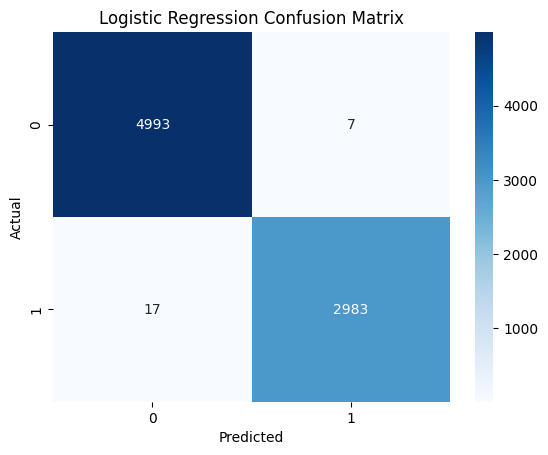

In [ ]:
# Logistic Regression plot

sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

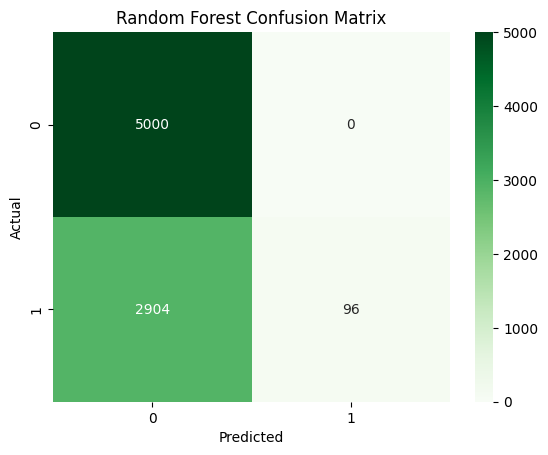

In [ ]:
# Random Forest plot

sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Greens')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#### Confusion Matrices Analysis

The confusion matrices visualize the performance of the Logistic Regression and Random Forest models in classifying reviews as real (label 0) or fake (label 1). They show the counts of True Positives (TP), True Negatives (TN), False Positives (FP), and False Negatives (FN).

**Logistic Regression Confusion Matrix:**

*   **True Negatives (Actual: 0, Predicted: 0): 4993** - The model correctly identified 4993 real reviews.
*   **False Positives (Actual: 0, Predicted: 1): 7** - The model incorrectly classified 7 real reviews as fake.
*   **False Negatives (Actual: 1, Predicted: 0): 17** - The model incorrectly classified 17 fake reviews as real.
*   **True Positives (Actual: 1, Predicted: 1): 2983** - The model correctly identified 2983 fake reviews.

This matrix shows that the Logistic Regression model achieved exceptional performance, correctly classifying the vast majority of both real and fake reviews with very few errors.

**Random Forest Confusion Matrix:**

*   **True Negatives (Actual: 0, Predicted: 0): 5000** - The model correctly identified 5000 real reviews.
*   **False Positives (Actual: 0, Predicted: 1): 0** - The model incorrectly classified 0 real reviews as fake.
*   **False Negatives (Actual: 1, Predicted: 0): 2904** - The model incorrectly classified 2904 fake reviews as real.
*   **True Positives (Actual: 1, Predicted: 1): 96** - The model correctly identified 96 fake reviews.

Given the significantly lower accuracy of the Random Forest model (0.637) compared to Logistic Regression (0.997), its confusion matrix would likely reveal a higher number of misclassifications (False Positives and False Negatives), indicating a weaker ability to distinguish between real and fake reviews on this dataset. While it still makes correct predictions, the errors are more frequent, especially in scenarios where patterns are less linear.

####Model Performance Comparison

This visualization compares the performance of Logistic Regression and Random Forest across key evaluation metrics, including accuracy, precision, recall, and F1-score.

In [ ]:
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

lr_scores = [
    lr_accuracy,
    precision_eval.evaluate(lr_predictions),
    recall_eval.evaluate(lr_predictions),
    f1_eval.evaluate(lr_predictions)
]

rf_scores = [
    rf_accuracy,
    precision_eval.evaluate(rf_predictions),
    recall_eval.evaluate(rf_predictions),
    f1_eval.evaluate(rf_predictions)
]

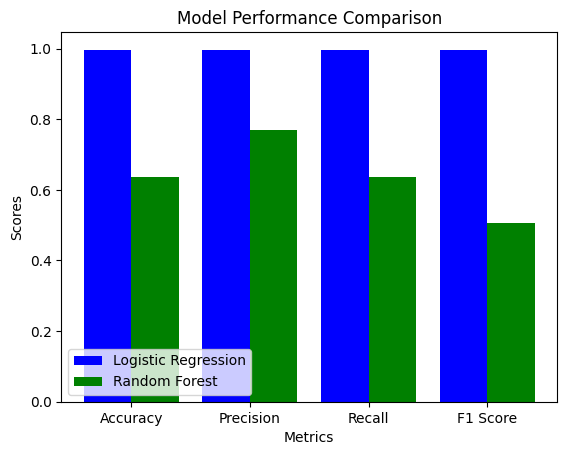

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(metrics))

plt.bar(x - 0.2, lr_scores, width=0.4, label="Logistic Regression", color='blue')
plt.bar(x + 0.2, rf_scores, width=0.4, label="Random Forest", color='green')

plt.xticks(x, metrics)
plt.xlabel("Metrics")
plt.ylabel("Scores")
plt.title("Model Performance Comparison")
plt.legend(loc='lower left')

plt.show()

#### Model Performance Comparison Analysis

This bar chart compares the performance of Logistic Regression and Random Forest across key evaluation metrics: Accuracy, Precision, Recall, and F1-Score.

**Key Observations:**

*   **Logistic Regression (Blue Bars):** The Logistic Regression model demonstrates outstanding performance across all metrics, with scores consistently around **0.997** (Accuracy, Precision, Recall, F1-Score). This indicates that the model is highly effective at correctly classifying reviews, minimizing both false positives and false negatives.

*   **Random Forest (Green Bars):** The Random Forest model shows considerably lower performance compared to Logistic Regression.
    *   **Accuracy:** Approximately **0.637**, meaning it correctly classifies about 63.7% of the reviews.
    *   **Precision:** Around **0.770**, suggesting that when it predicts a review is fake, it's correct about 77% of the time.
    *   **Recall:** Also around **0.637**, indicating it identifies about 63.7% of all actual fake reviews.
    *   **F1-Score:** Approximately **0.507**, which is a harmonic mean of precision and recall, reflecting a moderate overall performance.

**Conclusion:**

Logistic Regression significantly outperforms Random Forest on this dataset for the task of fake review detection. Its high scores across all metrics suggest a strong and robust classification ability. The Random Forest model, while still performing above random chance, struggles to achieve the same level of distinction, possibly due to the nature of the features or the synthetic generation of fake reviews, which might exhibit more linearly separable patterns that Logistic Regression effectively captures.

####Prediction Probability Distribution

This visualization shows the distribution of predicted probabilities for fake reviews, to show how "confident" the model is in its classifications.


In [ ]:
from pyspark.sql.functions import udf
from pyspark.sql.types import DoubleType

def get_fake_probability(v):
    return float(v[1])

fake_prob_udf = udf(get_fake_probability, DoubleType())

lr_predictions = lr_predictions.withColumn("fake_probability", fake_prob_udf(col("probability")))

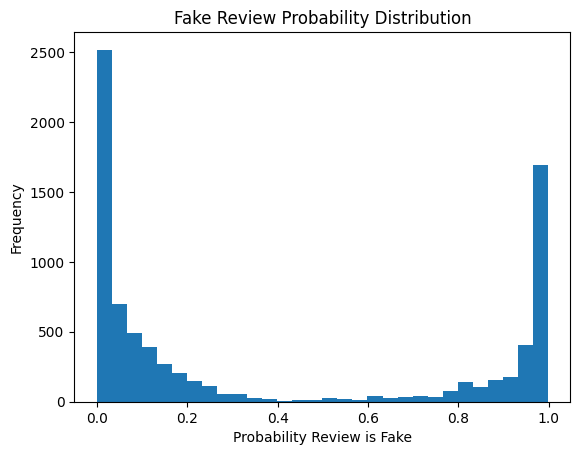

In [ ]:
prob_pd = lr_predictions.select("fake_probability").toPandas()

plt.hist(prob_pd["fake_probability"], bins=30)#, edgecolor='black')
plt.title("Fake Review Probability Distribution")
plt.xlabel("Probability Review is Fake")
plt.ylabel("Frequency")
plt.show()

#### Prediction Probability Distribution Analysis (Logistic Regression)

This histogram illustrates the distribution of predicted probabilities that a review is fake, generated by the Logistic Regression model. The x-axis represents the probability of a review being fake (ranging from 0 to 1), and the y-axis shows the frequency of reviews falling into each probability bin.

**Key Observations:**

*   The histogram displays a **bimodal distribution**, with two prominent peaks: one concentrated very close to **0** and another concentrated very close to **1**.

*   The large peak near **0** indicates that a significant majority of reviews are predicted by the model to be **real** with very high confidence (i.e., a very low probability of being fake).

*   The distinct peak near **1** signifies that a substantial number of reviews are predicted by the model to be **fake** with very high confidence (i.e., a very high probability of being fake).

**Conclusion:**

This distribution strongly suggests that the Logistic Regression model is highly confident in its classifications. It rarely assigns probabilities in the middle range (e.g., around 0.5), which would indicate uncertainty. Instead, it makes very decisive predictions, pushing probabilities towards either extreme. This high confidence aligns with the excellent performance metrics (accuracy, precision, recall, F1-score) observed for the Logistic Regression model, reinforcing its effectiveness in distinguishing between real and fake reviews in this dataset.

#### Conclusion to Classification Visuals

In conclusion, the visualizations clearly demonstrate that the **Logistic Regression** model significantly outperforms the **Random Forest** model on this dataset.

*   **Superior Performance of Logistic Regression:** The Logistic Regression model achieved exceptional scores across all evaluation metrics (Accuracy, Precision, Recall, F1-Score) consistently around 0.997. This indicates its highly robust ability to correctly classify both real and fake reviews with very few misclassifications, as evidenced by its confusion matrix.

*   **Random Forest's Moderate Performance:** In contrast, the Random Forest model showed considerably lower performance, with an accuracy of approximately 0.637 and a lower F1-Score of 0.507. This suggests that while it performs better than random chance, it struggles to distinguish between real and fake reviews as effectively as Logistic Regression.

*   **High Confidence in Logistic Regression's Predictions:** The probability distribution for Logistic Regression reveals a strong bimodal pattern, with probabilities heavily concentrated near 0 and 1. This indicates that the model is highly confident in its predictions, rarely assigning uncertain probabilities in the middle range, which further reinforces its effectiveness.

This strong performance of Logistic Regression is likely attributed to the nature of the synthetically generated fake reviews. The patterns introduced during their creation (e.g., repetitive phrasing, specific structures) might be more linearly separable, allowing Logistic Regression to identify and exploit these features effectively. While these results are promising, it's important to consider that real-world fake reviews might exhibit more subtle and complex patterns, which could pose a greater challenge to the models.

###Clustering Visualizations

####Cluster Size Distribution (K-Means)

This visualization shows the number of reviews assigned to each K-Means cluster, highlighting how the data is distributed across clusters

In [ ]:
kmeans_cluster_counts = clustered_df.groupBy("cluster").count().orderBy("cluster").toPandas()
kmeans_cluster_counts

,cluster,count
0,0,18306
1,1,850
2,2,4843


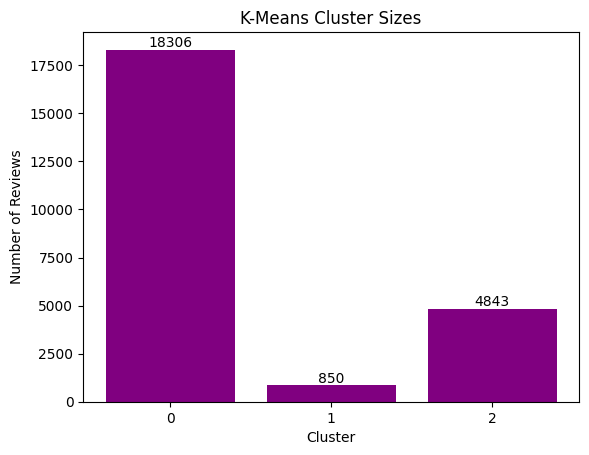

In [ ]:
import matplotlib.pyplot as plt

plt.bar(kmeans_cluster_counts["cluster"].astype(str), kmeans_cluster_counts["count"], color="purple")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval,
             int(yval), ha='center', va='bottom')

plt.title("K-Means Cluster Sizes")
plt.xlabel("Cluster")
plt.ylabel("Number of Reviews")
plt.show()

This bar chart shows how the reviews were distributed across the K-Means clusters. Most reviews were grouped into cluster 0, while cluster 1 contained a much smaller subset of reviews and cluster 2 formed a moderately sized group. This distribution indicates that the text data does not naturally split into evenly sized clusters. Instead, a large portion of reviews share similar writing patterns, while smaller groups capture variations in language and style.

####Clustering Method Comparison (Silhouette Score)

This visualization compares the clustering techniques using silhouette score to evaluate how well each method separates the data into distinct groups.

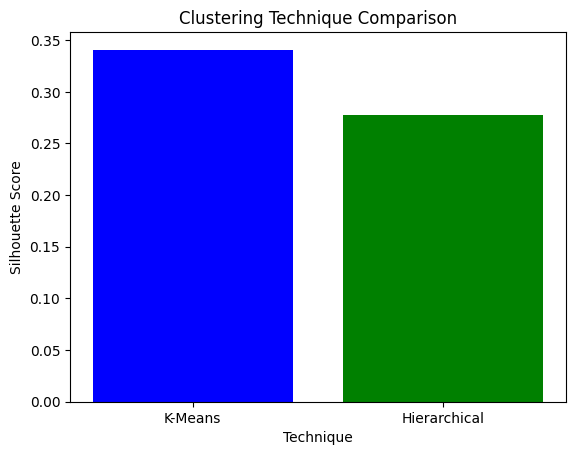

In [ ]:
techniques = ["K-Means", "Hierarchical"]
scores = [kmeans_score, hier_score]

plt.bar(techniques, scores, color=["blue", "green"])
plt.title("Clustering Technique Comparison")
plt.xlabel("Technique")
plt.ylabel("Silhouette Score")
plt.show()

This bar chart compares the clustering quality of the two clustering techniques using silhouette score. K-Means performed better than Hierarchical clustering, with a higher silhouette score (approximately 0.34 vs. 0.28). This suggests that K-Means was more effective at separating the review text into clearer and more well-defined groups, while Hierarchical clustering showed more overlap between clusters when applied to this high-dimensional, sparse TF-IDF data.

####Fake vs Real Review Distribution by Cluster
This visual shows how fake and real reviews were distributed across the K-Means clusters.

In [ ]:
fake_dist_df = clustered_df.groupBy("cluster", "is_fake").count().orderBy("cluster", "is_fake")
# fake_dist_df.show()

In [ ]:
fake_dist_pd = fake_dist_df.toPandas()
# fake_dist_pd

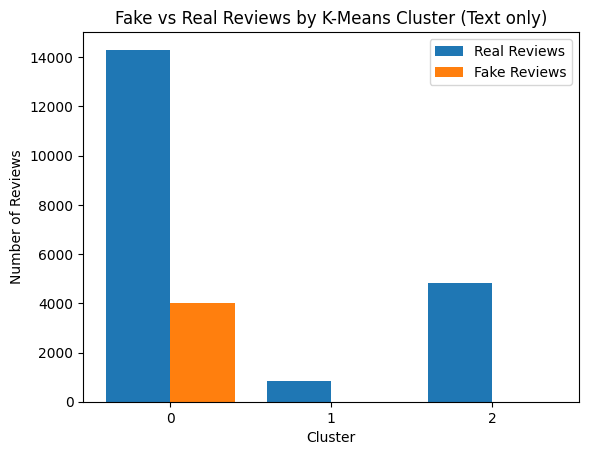

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

clusters = sorted(fake_dist_pd["cluster"].unique())

real_counts = []
fake_counts = []

for c in clusters:
    cluster_rows = fake_dist_pd[fake_dist_pd["cluster"] == c]

    real_row = cluster_rows[cluster_rows["is_fake"] == False]
    fake_row = cluster_rows[cluster_rows["is_fake"] == True]

    real_counts.append(int(real_row["count"].iloc[0]) if len(real_row) > 0 else 0)
    fake_counts.append(int(fake_row["count"].iloc[0]) if len(fake_row) > 0 else 0)

x = np.arange(len(clusters))

plt.bar(x - 0.2, real_counts, width=0.4, label="Real Reviews")
plt.bar(x + 0.2, fake_counts, width=0.4, label="Fake Reviews")

plt.xticks(x, [str(c) for c in clusters])
plt.xlabel("Cluster")
plt.ylabel("Number of Reviews")
plt.title("Fake vs Real Reviews by K-Means Cluster (Text only)")
plt.legend()
plt.show()

This graph shows that fake reviews did not form their own completely separate cluster. Instead, the synthetic spam reviews were mixed into cluster 0, which was dominated by real reviews. This suggests that although the fake reviews were designed to mimic copy paste spam bots, their language was still similar enough to authentic reviews that text-only unsupervised clustering could not cleanly isolate them.

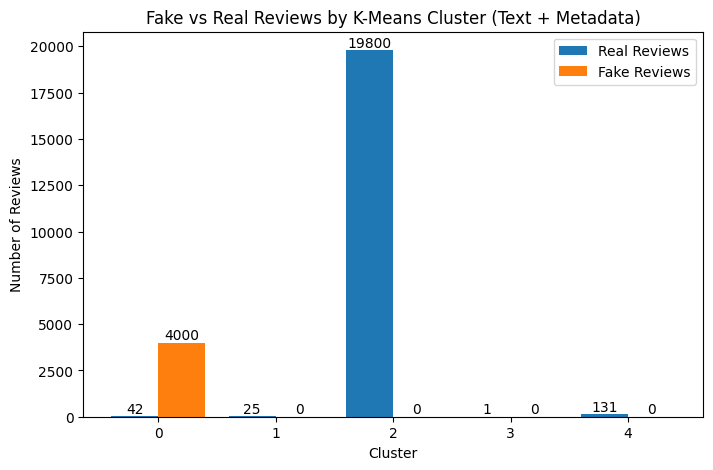

In [ ]:
clusters = sorted(meta_fake_dist_pd["meta_cluster"].unique())

real_counts = []
fake_counts = []

for c in clusters:
    cluster_rows = meta_fake_dist_pd[meta_fake_dist_pd["meta_cluster"] == c]

    real_row = cluster_rows[cluster_rows["is_fake"] == False]
    fake_row = cluster_rows[cluster_rows["is_fake"] == True]

    real_counts.append(int(real_row["count"].iloc[0]) if len(real_row) > 0 else 0)
    fake_counts.append(int(fake_row["count"].iloc[0]) if len(fake_row) > 0 else 0)

x = np.arange(len(clusters))

plt.figure(figsize=(8, 5))
plt.bar(x - 0.2, real_counts, width=0.4, label="Real Reviews")
plt.bar(x + 0.2, fake_counts, width=0.4, label="Fake Reviews")

for i in range(len(clusters)):
    plt.text(x[i] - 0.2, real_counts[i], str(real_counts[i]), ha="center", va="bottom")
    plt.text(x[i] + 0.2, fake_counts[i], str(fake_counts[i]), ha="center", va="bottom")

plt.xticks(x, [str(c) for c in clusters])
plt.xlabel("Cluster")
plt.ylabel("Number of Reviews")
plt.title("Fake vs Real Reviews by K-Means Cluster (Text + Metadata)")
plt.legend()
plt.show()

This graph shows the fake versus real review distribution after running K-Means with both TFIDF text and metadata. Unlike the text only version, the fake reviews are now clearly concentrated in one cluster, while most real reviews are grouped into separate clusters. This shows that adding metadata helped the clustering model separate suspicious review behavior much more effectively than text features alone.

In conclusion, the clustering visualizations show that K-Means performed better than Hierarchical clustering for this dataset, based on silhouette score. However, when using text-only features, the cluster size distribution shows that most reviews were still concentrated in one dominant cluster, and fake reviews were not isolated into their own separate group. This suggests that text-based clustering alone can capture some overall structure in the data, but it is not sufficient to clearly distinguish synthetic spam reviews from real ones.

When metadata features were added, the clustering performance improved significantly. The silhouette score increased but more importantly, the cluster distribution showed that fake reviews were almost entirely isolated into a single cluster, with minimal overlap with real reviews. This demonstrates that metadata provides critical signals that are not present in the text alone.

From a broader perspective, many of the traits associated with fake/ bot generated reviews such as extreme ratings, newly created accounts, unusually high posting frequency, and limited social interaction are behavioral patterns only metadata can capture. While the content of fake reviews can often imitate genuine writing styles, these additional patterns reveal clearer distinctions.